## Technical Part

In [1]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

### Загрузим библиотеки

In [2]:
%pip install opendatasets

import opendatasets as od
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
SEED = 1208
np.random.seed(SEED)

### Загрузим датасет

In [4]:
#upload dataset from kaggle
cwd = os.getcwd()

od.download("https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/data", path=cwd, force=True)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: c
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022


100%|██████████| 532M/532M [00:05<00:00, 93.3MB/s]


In [5]:
data_pdf = pd.read_csv("/content/bank-account-fraud-dataset-neurips-2022/Base.csv")
data_pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

### Создадим доп функции

In [6]:
# поиск выбросов по алгоритму
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

## Analysis of dataset

###Зависимая переменная

Прежде чем переходить к анализу признаков, оценим распределение целевой переменной `fraud_bool`.
Дисбаланс классов — ключевая характеристика задачи, которая влияет на все последующие решения:
выбор метрики, стратегию сэмплинга и архитектуру модели.

In [128]:
# --- Базовая статистика ---
fraud_counts = data_pdf['fraud_bool'].value_counts()
fraud_rate   = data_pdf['fraud_bool'].mean()
total        = len(data_pdf)

print("=" * 45)
print(f"  Всего записей:          {total:>10,}")
print(f"  Легитимных (0):         {fraud_counts[0]:>10,}  ({fraud_counts[0]/total:.2%})")
print(f"  Фродовых   (1):         {fraud_counts[1]:>10,}  ({fraud_counts[1]/total:.2%})")
print(f"  Соотношение fraud:legit  1 : {fraud_counts[0]/fraud_counts[1]:.0f}")
print("=" * 45)

  Всего записей:           1,000,000
  Легитимных (0):            988,971  (98.90%)
  Фродовых   (1):             11,029  (1.10%)
  Соотношение fraud:legit  1 : 90


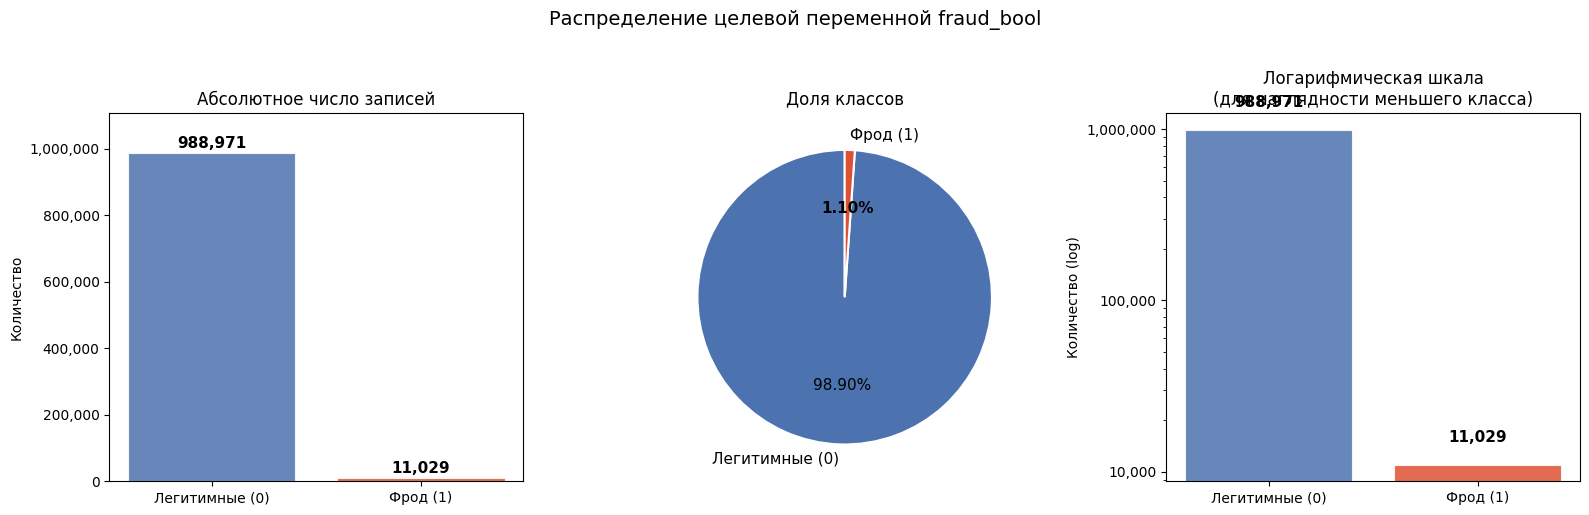

In [130]:
# --- Визуализация ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Распределение целевой переменной fraud_bool', fontsize=14, y=1.02)

COLORS = ['#4C72B0', '#DD5133']

# 1. Bar chart с абсолютными числами
bars = axes[0].bar(
    ['Легитимные (0)', 'Фрод (1)'],
    fraud_counts.values,
    color=COLORS, alpha=0.85, edgecolor='white', linewidth=0.8
)
axes[0].set_title('Абсолютное число записей')
axes[0].set_ylabel('Количество')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, fraud_counts[0] * 1.12)

# 2. Pie chart с процентами
wedges, texts, autotexts = axes[1].pie(
    fraud_counts.values,
    labels=['Легитимные (0)', 'Фрод (1)'],
    colors=COLORS,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=11)
)
autotexts[1].set_fontweight('bold')
axes[1].set_title('Доля классов')

# 3. Log-scale bar — чтобы фрод был виден
axes[2].bar(
    ['Легитимные (0)', 'Фрод (1)'],
    fraud_counts.values,
    color=COLORS, alpha=0.85, edgecolor='white', linewidth=0.8
)
axes[2].set_yscale('log')
axes[2].set_title('Логарифмическая шкала\n(для наглядности меньшего класса)')
axes[2].set_ylabel('Количество (log)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(axes[2].patches, fraud_counts.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.3,
        f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

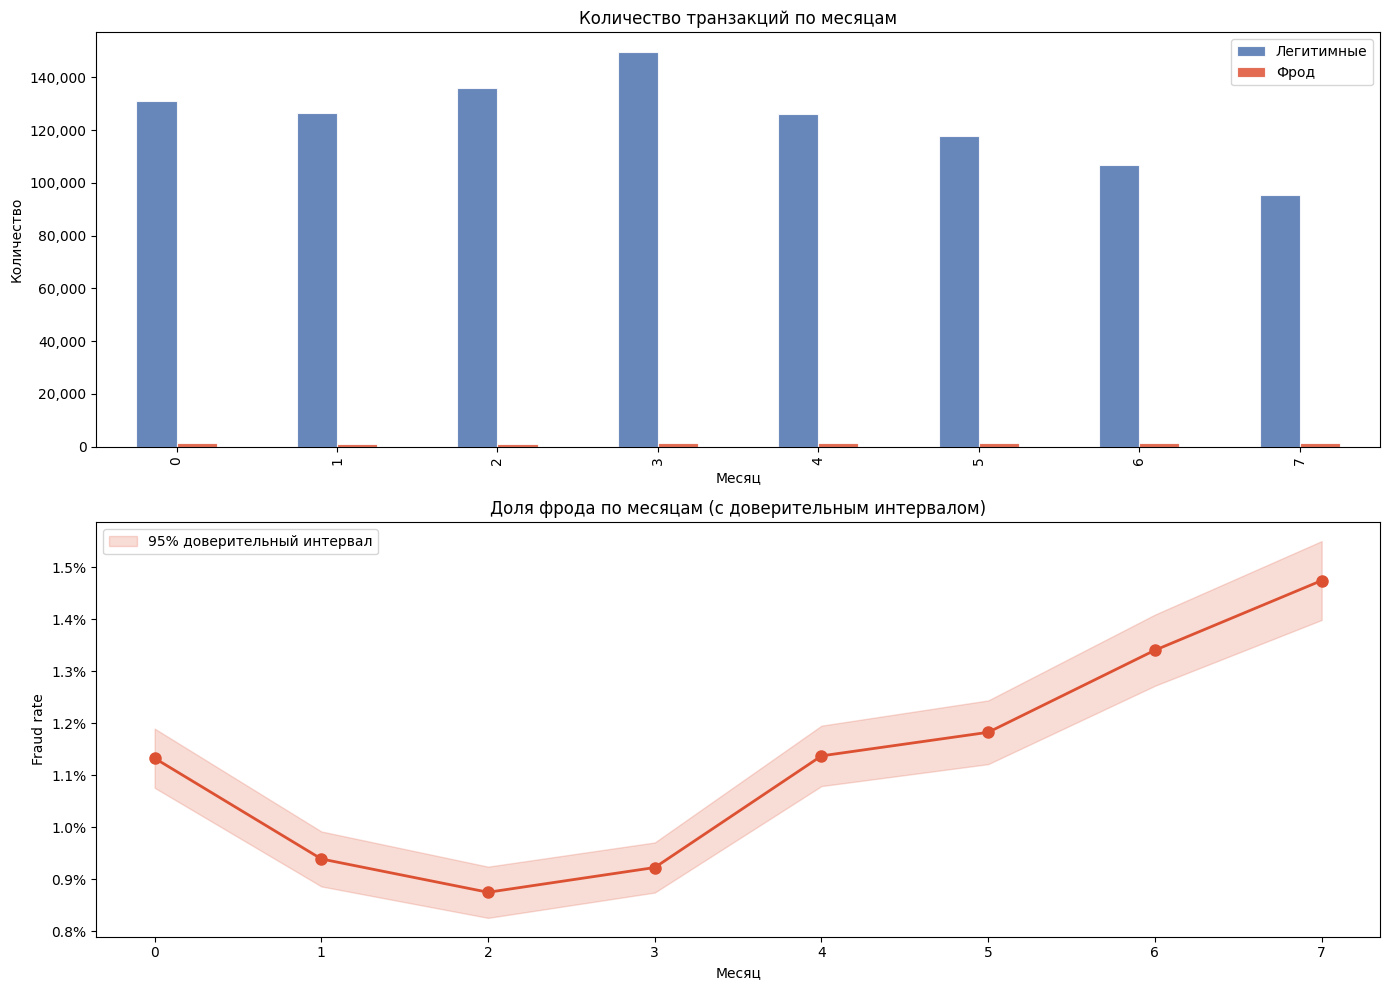

In [131]:
#Let's check for changes of fraud cases in time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1а. Абсолютное число фродов и легитимных по месяцам
monthly_counts = data_pdf.groupby(['month', 'fraud_bool']).size().unstack()
monthly_counts.plot(
    kind='bar', ax=axes[0],
    color=['#4C72B0', '#DD5133'], alpha=0.85,
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Количество транзакций по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество')
axes[0].legend(['Легитимные', 'Фрод'])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 1б. Доля фрода по месяцам + доверительный интервал
monthly = data_pdf.groupby('month')['fraud_bool'].agg(['mean', 'count'])
monthly['se'] = np.sqrt(
    monthly['mean'] * (1 - monthly['mean']) / monthly['count']
)

axes[1].plot(monthly.index, monthly['mean'],
             marker='o', color='#DD5133', linewidth=2, markersize=8)
axes[1].fill_between(
    monthly.index,
    monthly['mean'] - 1.96 * monthly['se'],
    monthly['mean'] + 1.96 * monthly['se'],
    alpha=0.2, color='#DD5133', label='95% доверительный интервал'
)
axes[1].set_title('Доля фрода по месяцам (с доверительным интервалом)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Fraud rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].legend()

plt.tight_layout()
plt.show()

###Независимые переменные

In [8]:
data_pdf.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [9]:
# Basic analysis for duplicates
duplicates = data_pdf.duplicated()
number_of_duplicates = duplicates.sum()
print(f"Количество полных дубликатов в датасете: {number_of_duplicates}")

Количество полных дубликатов в датасете: 0


In [10]:
# Checking for nulls
print(data_pdf.isnull().sum())

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

In [11]:
# найдем выбросы
numeric_cols  = data_pdf.dtypes[data_pdf.dtypes.isin(['int64', 'float64'])].index.tolist()
for x in numeric_cols:
  outl = find_outliers(data_pdf, f'{x}')
  print(f'Выбросы по {x}: {len(outl)}')

In [12]:
data_pdf.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


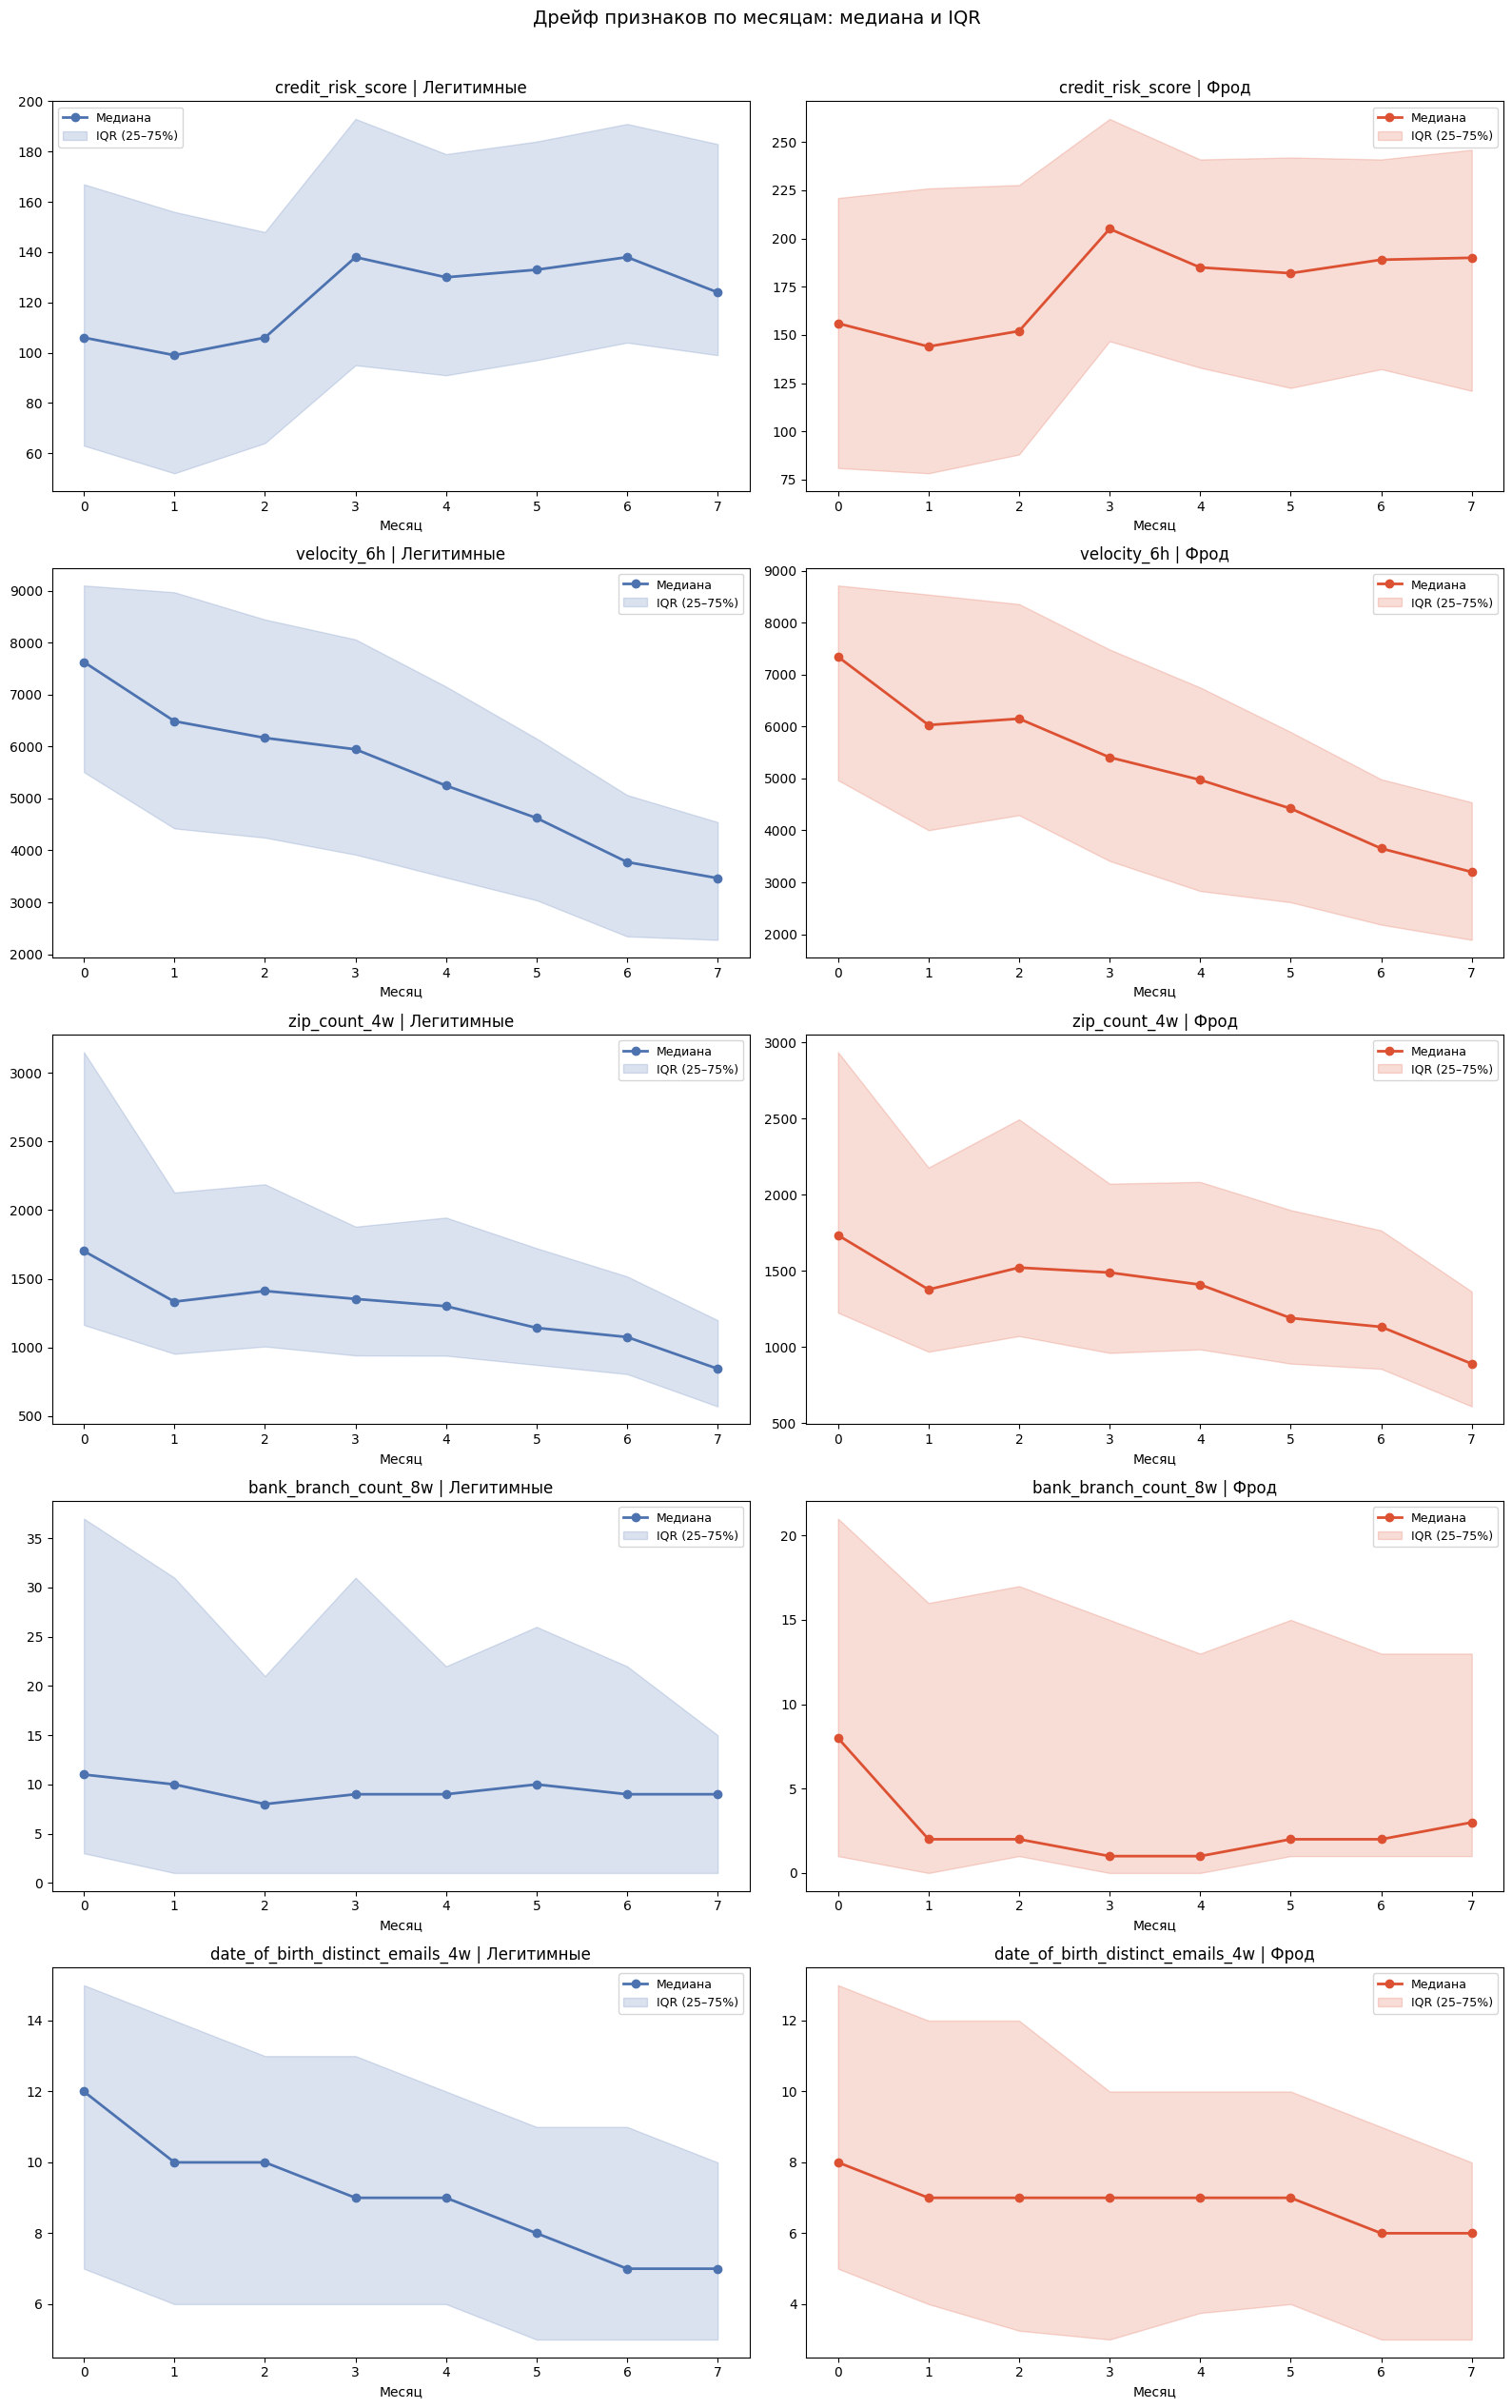

In [133]:
#посмотрим на дрейф ключевых признаков
key_features = [
    'credit_risk_score',
    'velocity_6h',
    'zip_count_4w',
    'bank_branch_count_8w',
    'date_of_birth_distinct_emails_4w'
]

fig, axes = plt.subplots(len(key_features), 2, figsize=(16, 5 * len(key_features)))
fig.suptitle('Дрейф признаков по месяцам: медиана и IQR', fontsize=14, y=1.01)

for i, feat in enumerate(key_features):
    for j, (fraud_val, label, color) in enumerate([
        (0, 'Легитимные', '#4C72B0'),
        (1, 'Фрод',       '#DD5133')
    ]):
        ax = axes[i][j]
        subset = data_pdf[data_pdf['fraud_bool'] == fraud_val]

        monthly_stats = subset.groupby('month')[feat].agg([
            ('median', 'median'),
            ('q25',    lambda x: x.quantile(0.25)),
            ('q75',    lambda x: x.quantile(0.75))
        ])

        ax.plot(monthly_stats.index, monthly_stats['median'],
                marker='o', color=color, linewidth=2, label='Медиана')
        ax.fill_between(
            monthly_stats.index,
            monthly_stats['q25'],
            monthly_stats['q75'],
            alpha=0.2, color=color, label='IQR (25–75%)'
        )
        ax.set_title(f'{feat} | {label}')
        ax.set_xlabel('Месяц')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

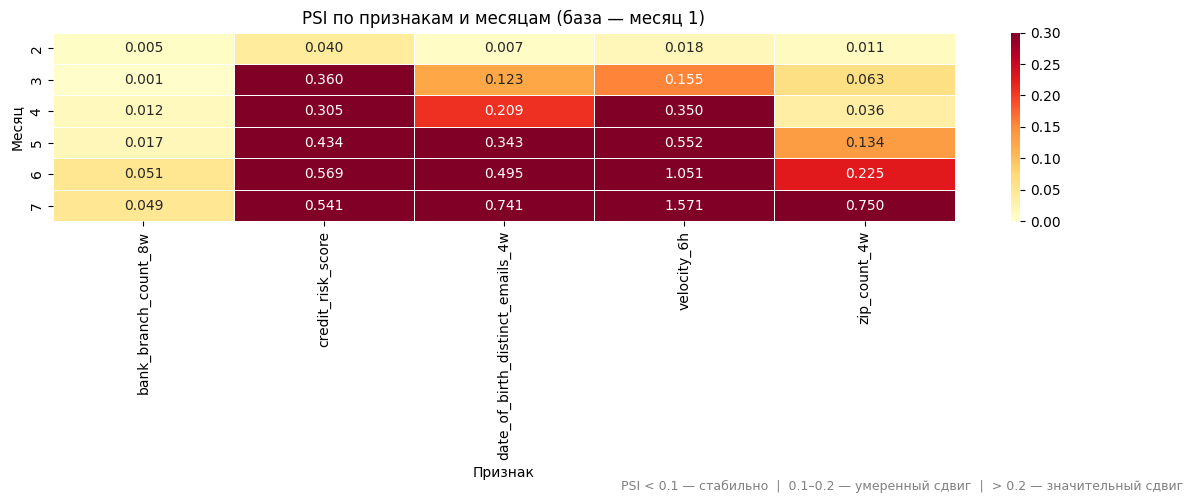

Признаки со значительным дрейфом (PSI > 0.2 хотя бы в одном месяце):
['credit_risk_score', 'date_of_birth_distinct_emails_4w', 'velocity_6h', 'zip_count_4w']

Признаки с умеренным дрейфом (PSI 0.1–0.2):
['date_of_birth_distinct_emails_4w', 'velocity_6h', 'zip_count_4w']


In [134]:
#посмотрим на PSI
def calc_psi(base, current, bins=10):
    breakpoints = np.linspace(
        min(base.min(), current.min()),
        max(base.max(), current.max()),
        bins + 1
    )
    base_pct    = np.histogram(base,    bins=breakpoints)[0] / len(base)
    current_pct = np.histogram(current, bins=breakpoints)[0] / len(current)
    base_pct    = np.where(base_pct    == 0, 1e-6, base_pct)
    current_pct = np.where(current_pct == 0, 1e-6, current_pct)
    return np.sum((current_pct - base_pct) * np.log(current_pct / base_pct))

# месяц 1 — база, остальные сравниваем с ней
base_month = data_pdf[data_pdf['month'] == 1]
psi_results = []

for month in range(2, data_pdf['month'].max() + 1):
    current_month = data_pdf[data_pdf['month'] == month]
    for feat in key_features:
        psi = calc_psi(
            base_month[feat].dropna(),
            current_month[feat].dropna()
        )
        psi_results.append({
            'month':   month,
            'feature': feat,
            'PSI':     round(psi, 4)
        })

psi_df = pd.DataFrame(psi_results).pivot(
    index='month', columns='feature', values='PSI'
)

# визуализация PSI как heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(
    psi_df,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0, vmax=0.3
)
plt.title('PSI по признакам и месяцам (база — месяц 1)')
plt.xlabel('Признак')
plt.ylabel('Месяц')

# добавим легенду порогов
plt.figtext(0.99, 0.01,
    'PSI < 0.1 — стабильно  |  0.1–0.2 — умеренный сдвиг  |  > 0.2 — значительный сдвиг',
    ha='right', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

# итоговый вывод по признакам
print("Признаки со значительным дрейфом (PSI > 0.2 хотя бы в одном месяце):")
drifted = psi_df.columns[(psi_df > 0.2).any()].tolist()
print(drifted if drifted else "Не обнаружено")

print("\nПризнаки с умеренным дрейфом (PSI 0.1–0.2):")
moderate = psi_df.columns[((psi_df > 0.1) & (psi_df <= 0.2)).any()].tolist()
print(moderate if moderate else "Не обнаружено")

## Разделение на train-test и oot
train и test будут использоваться для обучения и тестирования модели.
oot будет использоваться для тестирования прогнозной способности модели.

oot - будут 2 последних месяца в выборке
train и test - будут разделены случайным образом в соотношении 80\20 позже, после анализа переменных

In [13]:
df_oot = data_pdf[data_pdf['month'] > 5]
df_train_test = data_pdf[data_pdf['month'] <= 5]

In [14]:
df_oot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205011 entries, 794989 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        205011 non-null  int64  
 1   income                            205011 non-null  float64
 2   name_email_similarity             205011 non-null  float64
 3   prev_address_months_count         205011 non-null  int64  
 4   current_address_months_count      205011 non-null  int64  
 5   customer_age                      205011 non-null  int64  
 6   days_since_request                205011 non-null  float64
 7   intended_balcon_amount            205011 non-null  float64
 8   payment_type                      205011 non-null  object 
 9   zip_count_4w                      205011 non-null  int64  
 10  velocity_6h                       205011 non-null  float64
 11  velocity_24h                      205011 non-null  f

In [15]:
df_train_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794989 entries, 0 to 794988
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        794989 non-null  int64  
 1   income                            794989 non-null  float64
 2   name_email_similarity             794989 non-null  float64
 3   prev_address_months_count         794989 non-null  int64  
 4   current_address_months_count      794989 non-null  int64  
 5   customer_age                      794989 non-null  int64  
 6   days_since_request                794989 non-null  float64
 7   intended_balcon_amount            794989 non-null  float64
 8   payment_type                      794989 non-null  object 
 9   zip_count_4w                      794989 non-null  int64  
 10  velocity_6h                       794989 non-null  float64
 11  velocity_24h                      794989 non-null  float6

## Очистка данных
Сфокусируемся на данных трейн-тест.

Так как данные несбалансированные, будет анализировать данные отдельно для фродовых строк и не-фродовых. Чтобы анализ пустышек\выбросов был более честным

In [16]:
df_train_test['fraud_bool'].value_counts()

,count
fraud_bool,
0,786838
1,8151


/tmp/ipykernel_16174/1982989809.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_16174/1982989809.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_16174/1982989809.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_16174/1982989809.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_16174/1982989809.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

IndexError: index 5 is out of bounds for axis 0 with size 5

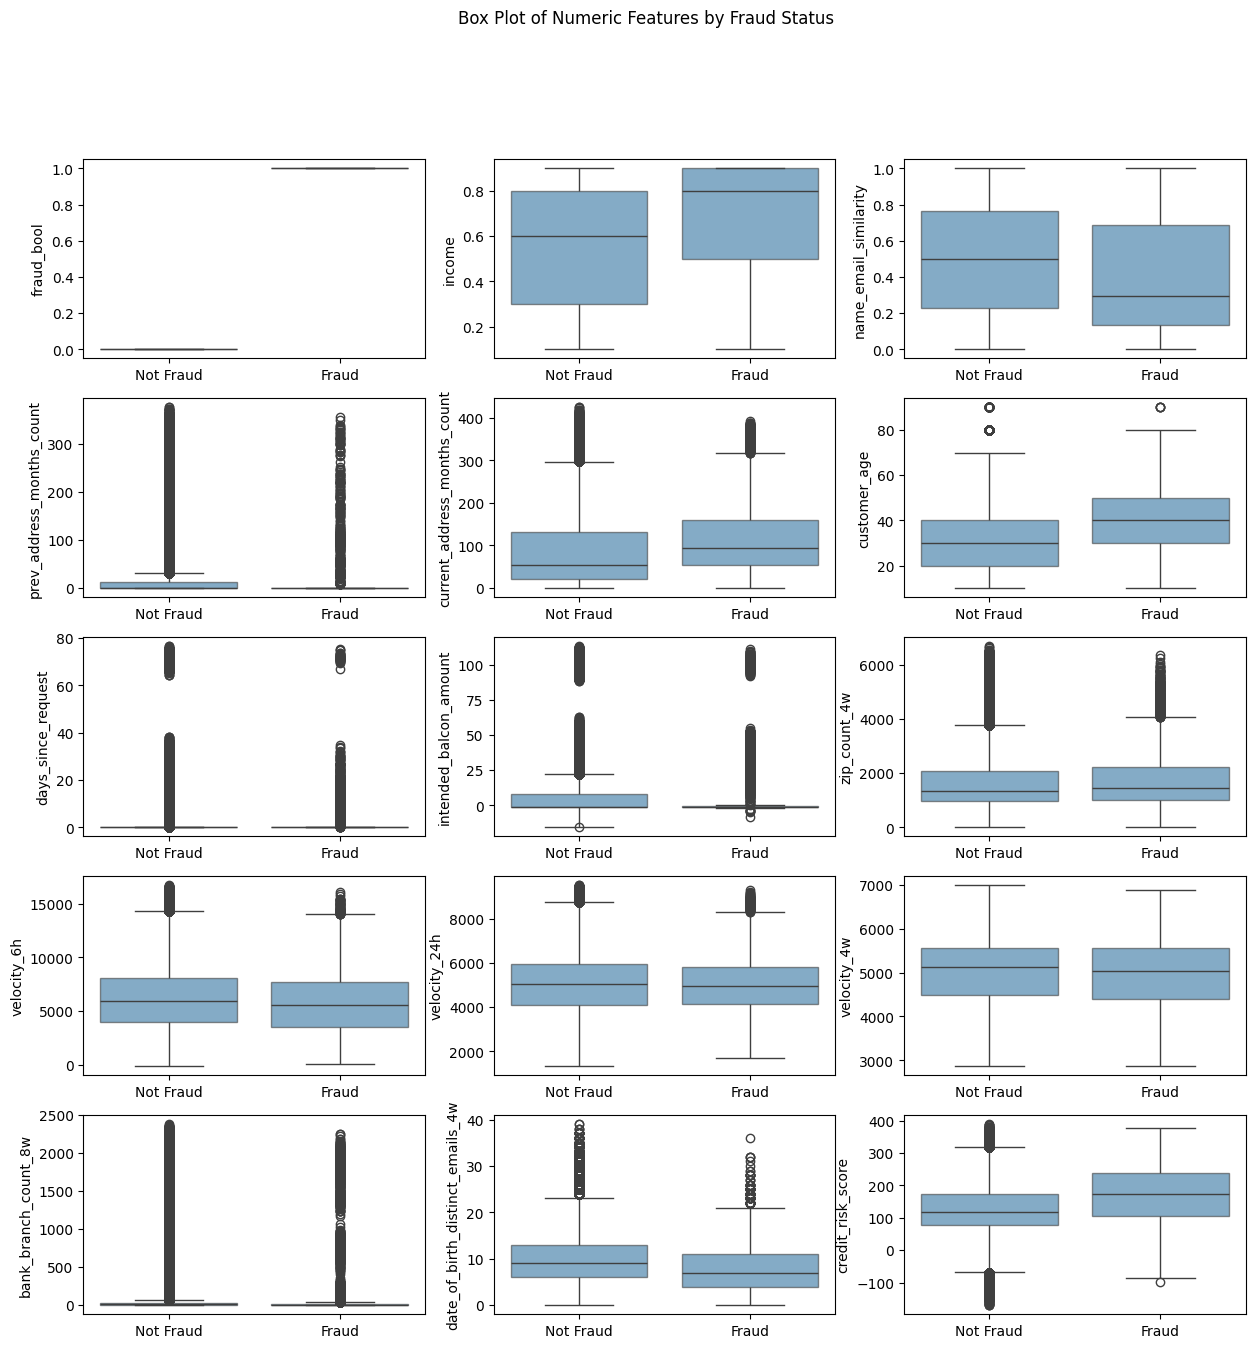

In [17]:
# Create a grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Add a title to the figure
fig.suptitle('Box Plot of Numeric Features by Fraud Status')

# Loop through the numeric features and plot a box plot for each feature
num_columns = list(df_train_test.select_dtypes(include=['float64', 'int64']).columns)

for i, feature in enumerate(num_columns):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df_train_test, x='fraud_bool', y=feature, ax=ax, boxprops=dict(alpha=.6))
    ax.set_xlabel('')
    ax.set_ylabel(feature)
    ax.set_xticklabels(['Not Fraud', 'Fraud'])

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

Рассмотрим более подробно переменные с большим количеством выбросов

### prev_address_months_count
мы знаем, что (-1) здесь означает незаполненные данные

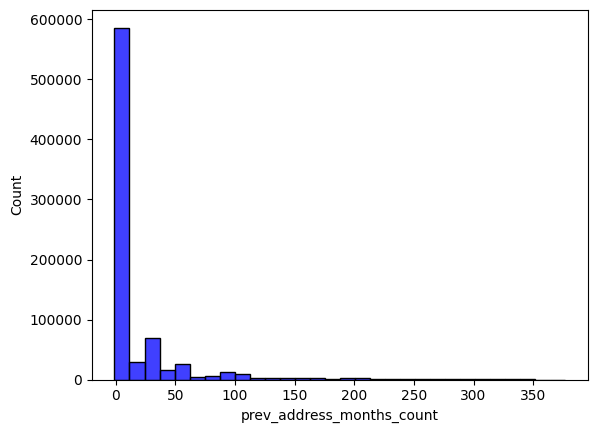

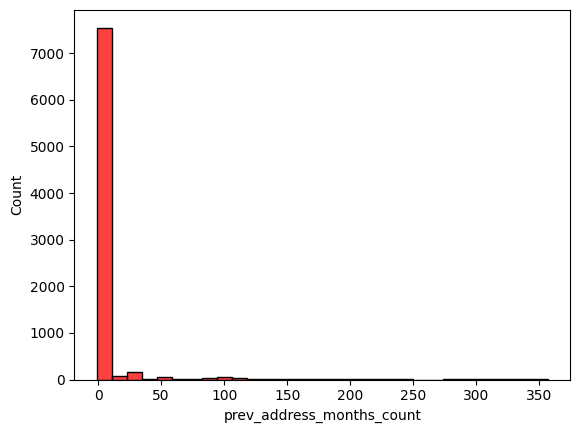

In [18]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['prev_address_months_count'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['prev_address_months_count'], bins=30, color='red')
plt.show()

In [19]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 0]['prev_address_months_count'].value_counts().head(5)
print(top_5)

prev_address_months_count
-1     560906
 11      9552
 10      8713
 28      8439
 27      8350
Name: count, dtype: int64


In [20]:
560906/786838
# 71% is NaNs

0.712860843019783

In [21]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 1]['prev_address_months_count'].value_counts().head(5)
print(top_5)

prev_address_months_count
-1     7517
 11      26
 28      24
 30      22
 12      21
Name: count, dtype: int64


In [22]:
7517/8151
# 91% are Nans

0.9222181327444485

In [23]:
#Так как процент заполненности более 95% в обеих подгруппах - заменим -1 на Nan
df_train_test['prev_address_months_count'] = df_train_test['prev_address_months_count'].replace({-1: np.nan})

/tmp/ipykernel_16174/2292905708.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_test['prev_address_months_count'] = df_train_test['prev_address_months_count'].replace({-1: np.nan})


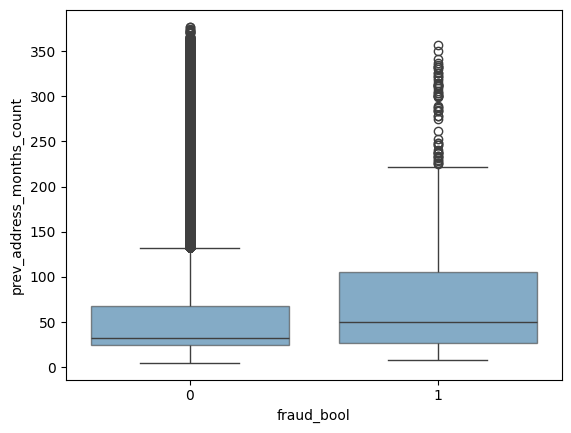

In [24]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='prev_address_months_count', boxprops=dict(alpha=.6))
plt.show()

In [25]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'prev_address_months_count')
print(f'Выбросы по prev_address_months_count NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'prev_address_months_count')
print(f'Выбросы по prev_address_months_count fraud: {len(outl)}')

Выбросы по prev_address_months_count NOT fraud: 23054
Выбросы по prev_address_months_count fraud: 59


In [26]:
df_train_test[df_train_test['fraud_bool'] == 0]['prev_address_months_count'].info()

df_train_test[df_train_test['fraud_bool'] == 1]['prev_address_months_count'].info()

<class 'pandas.core.series.Series'>
Index: 786838 entries, 0 to 794988
Series name: prev_address_months_count
Non-Null Count   Dtype  
--------------   -----  
225932 non-null  float64
dtypes: float64(1)
memory usage: 12.0 MB
<class 'pandas.core.series.Series'>
Index: 8151 entries, 43 to 794862
Series name: prev_address_months_count
Non-Null Count  Dtype  
--------------  -----  
634 non-null    float64
dtypes: float64(1)
memory usage: 127.4 KB


In [27]:
(225932-23054) /786838 #останется 26% чистых значений после очистки выбросов

0.2578396061196841

In [28]:
(634 - 59) /8151  #останется 7% чистых значений после очистки выбросов

0.07054349159612318

In [29]:
df_train_test['prev_address_months_count'].info()

<class 'pandas.core.series.Series'>
Index: 794989 entries, 0 to 794988
Series name: prev_address_months_count
Non-Null Count   Dtype  
--------------   -----  
226566 non-null  float64
dtypes: float64(1)
memory usage: 12.1 MB


In [30]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['prev_address_months_count'].quantile(0.25)
Q3 = df_nonF['prev_address_months_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['prev_address_months_count'] >= lower_bound) & (df_nonF['prev_address_months_count'] <= upper_bound)]['prev_address_months_count']

median_value_nonF = non_outliers.median()

df_nonF['prev_address_months_count_clean'] = np.where(
    (df_nonF['prev_address_months_count'] < lower_bound) | (df_nonF['prev_address_months_count'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['prev_address_months_count']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['prev_address_months_count'].quantile(0.25)
Q3 = df_F['prev_address_months_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['prev_address_months_count'] >= lower_bound) & (df_F['prev_address_months_count'] <= upper_bound)]['prev_address_months_count']

median_value_F = non_outliers.median()

df_F['prev_address_months_count_clean'] = np.where(
    (df_F['prev_address_months_count'] < lower_bound) | (df_F['prev_address_months_count'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['prev_address_months_count']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/3366436762.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['prev_address_months_count_clean'] = np.where(
/tmp/ipykernel_16174/3366436762.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['prev_address_months_count_clean'] = np.where(


### current_address_months_count
также знаем что -1 это пустышки

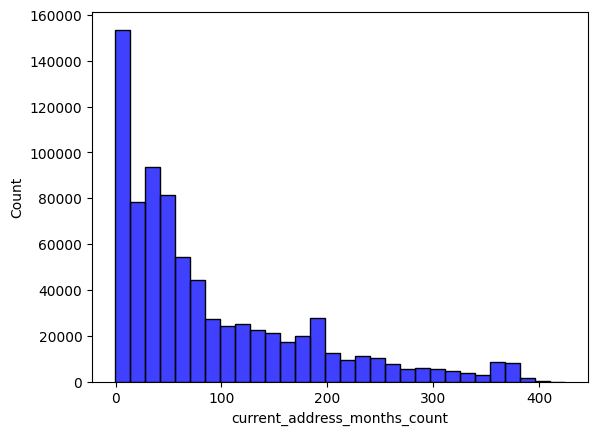

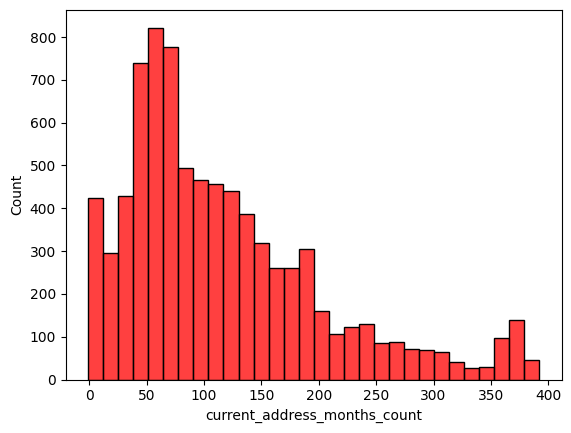

In [31]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['current_address_months_count'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['current_address_months_count'], bins=30, color='red')
plt.show()

In [32]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 0]['current_address_months_count'].value_counts().head(5)
print(top_5)

current_address_months_count
7    12534
6    12495
8    12432
9    12270
5    12080
Name: count, dtype: int64


In [33]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 1]['current_address_months_count'].value_counts().head(5)
print(top_5)

current_address_months_count
47    77
52    76
66    73
59    72
69    71
Name: count, dtype: int64


In [34]:
#-1 есть, но мало. заменим на НаН
df_train_test['current_address_months_count'] = df_train_test['current_address_months_count'].replace({-1: np.nan})

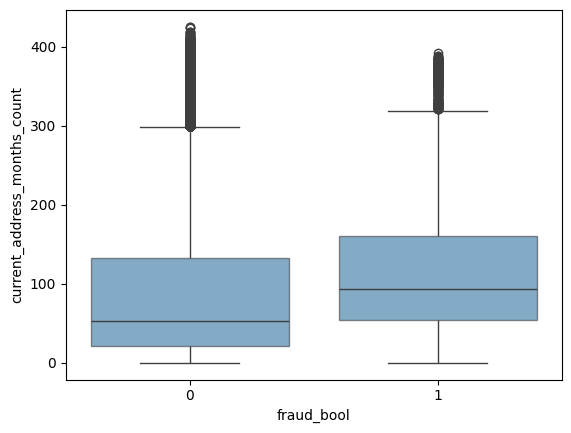

In [35]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='current_address_months_count', boxprops=dict(alpha=.6))
plt.show()

In [36]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'current_address_months_count')
print(f'Выбросы по current_address_months_count NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'current_address_months_count')
print(f'Выбросы по current_address_months_count fraud: {len(outl)}')

Выбросы по current_address_months_count NOT fraud: 34330
Выбросы по current_address_months_count fraud: 357


In [37]:
df_train_test[df_train_test['fraud_bool'] == 0]['current_address_months_count'].info()

df_train_test[df_train_test['fraud_bool'] == 1]['current_address_months_count'].info()

<class 'pandas.core.series.Series'>
Index: 786838 entries, 0 to 786837
Series name: current_address_months_count
Non-Null Count   Dtype  
--------------   -----  
783820 non-null  float64
dtypes: float64(1)
memory usage: 12.0 MB
<class 'pandas.core.series.Series'>
Index: 8151 entries, 786838 to 794988
Series name: current_address_months_count
Non-Null Count  Dtype  
--------------  -----  
8142 non-null   float64
dtypes: float64(1)
memory usage: 127.4 KB


In [38]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['current_address_months_count'].quantile(0.25)
Q3 = df_nonF['current_address_months_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['current_address_months_count'] >= lower_bound)
                        & (df_nonF['current_address_months_count'] <= upper_bound)]['current_address_months_count']

median_value_nonF = non_outliers.median()

df_nonF['current_address_months_count_clean'] = np.where(
    (df_nonF['current_address_months_count'] < lower_bound) | (df_nonF['current_address_months_count'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['current_address_months_count']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['current_address_months_count'].quantile(0.25)
Q3 = df_F['current_address_months_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['current_address_months_count'] >= lower_bound)
                      & (df_F['current_address_months_count'] <= upper_bound)]['current_address_months_count']

median_value_F = non_outliers.median()

df_F['current_address_months_count_clean'] = np.where(
    (df_F['current_address_months_count'] < lower_bound) | (df_F['current_address_months_count'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['current_address_months_count']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/2451369655.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['current_address_months_count_clean'] = np.where(
/tmp/ipykernel_16174/2451369655.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['current_address_months_count_clean'] = np.where(


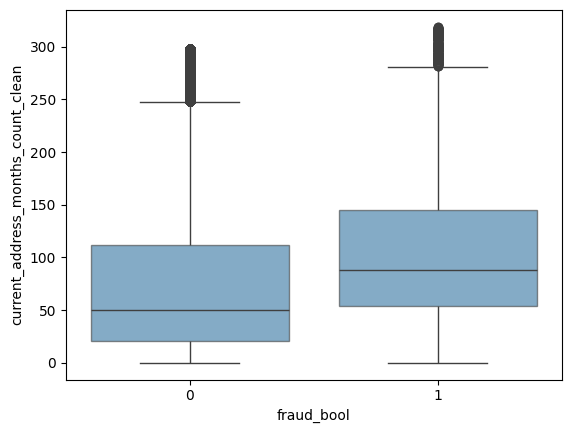

In [39]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='current_address_months_count_clean', boxprops=dict(alpha=.6))
plt.show()

### days_since_request

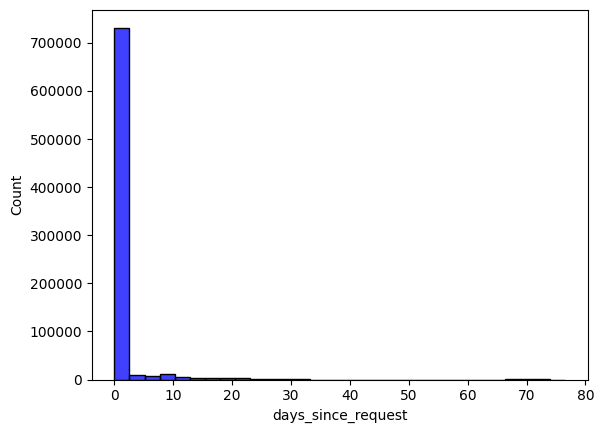

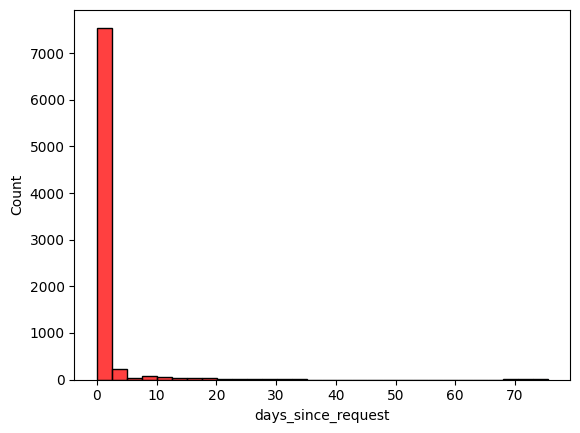

In [40]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['days_since_request'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['days_since_request'], bins=30, color='red')
plt.show()

In [41]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 0]['days_since_request'].value_counts().head(5)
print(top_5)

days_since_request
0.006703    3
0.031076    3
0.007416    3
0.014359    3
0.022408    3
Name: count, dtype: int64


In [42]:
#поле "количество дней", значения не круглые - давайте округлим, для анализа дальнейшего
df_train_test['days_since_request_rounded'] = df_train_test['days_since_request'].round()

top_5 = df_train_test[df_train_test['fraud_bool'] == 0]['days_since_request_rounded'].value_counts().head(5)
print(top_5)

days_since_request_rounded
0.0    708792
1.0     17499
3.0      6689
8.0      5233
9.0      5159
Name: count, dtype: int64


In [43]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 1]['days_since_request_rounded'].value_counts().head(5)
print(top_5)

days_since_request_rounded
0.0    7182
1.0     260
3.0     161
2.0     104
4.0      69
Name: count, dtype: int64


In [44]:
# теперь перекос очевиден
708792/786838

0.9008105861689446

In [45]:
7182/8151

0.8811188811188811

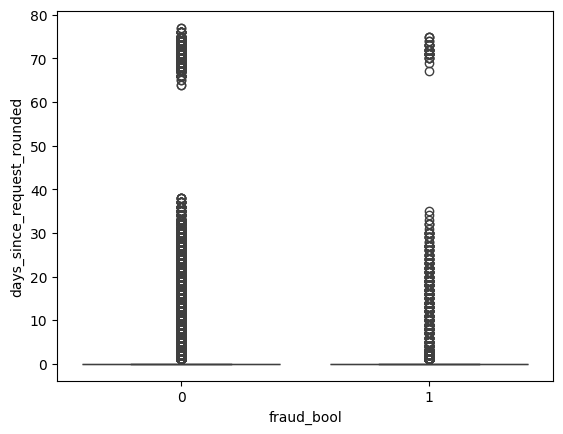

In [46]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='days_since_request_rounded', boxprops=dict(alpha=.6))
plt.show()

In [47]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'days_since_request_rounded')
print(f'Выбросы по days_since_request_rounded NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'days_since_request_rounded')
print(f'Выбросы по days_since_request_rounded fraud: {len(outl)}')

Выбросы по days_since_request_rounded NOT fraud: 78046
Выбросы по days_since_request_rounded fraud: 969


In [48]:
78046/786838

0.09918941383105544

In [49]:
969/8151

0.11888111888111888

In [50]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['days_since_request_rounded'].quantile(0.25)
Q3 = df_nonF['days_since_request_rounded'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['days_since_request_rounded'] >= lower_bound)
                        & (df_nonF['days_since_request_rounded'] <= upper_bound)]['days_since_request_rounded']

median_value_nonF = non_outliers.median()

df_nonF['days_since_request_rounded_clean'] = np.where(
    (df_nonF['days_since_request_rounded'] < lower_bound) | (df_nonF['days_since_request_rounded'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['days_since_request_rounded']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['days_since_request_rounded'].quantile(0.25)
Q3 = df_F['days_since_request_rounded'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['days_since_request_rounded'] >= lower_bound)
                      & (df_F['days_since_request_rounded'] <= upper_bound)]['days_since_request_rounded']

median_value_F = non_outliers.median()

df_F['days_since_request_rounded_clean'] = np.where(
    (df_F['days_since_request_rounded'] < lower_bound) | (df_F['days_since_request_rounded'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['days_since_request_rounded']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/3504439419.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['days_since_request_rounded_clean'] = np.where(
/tmp/ipykernel_16174/3504439419.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['days_since_request_rounded_clean'] = np.where(


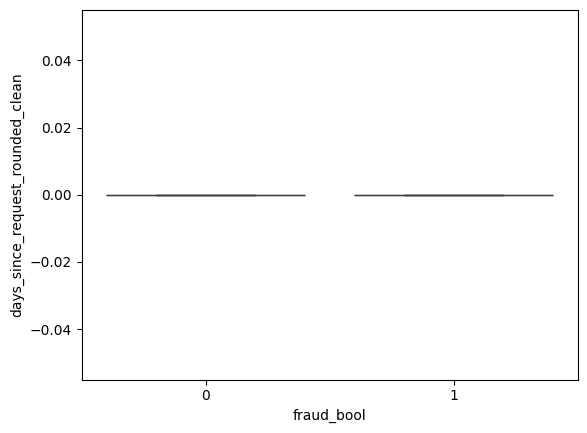

In [51]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='days_since_request_rounded_clean', boxprops=dict(alpha=.6))
plt.show()

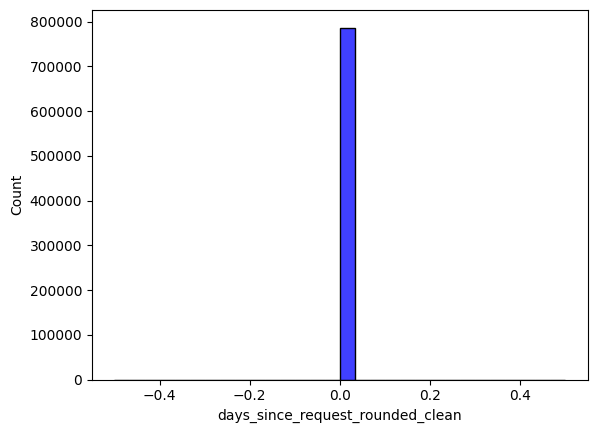

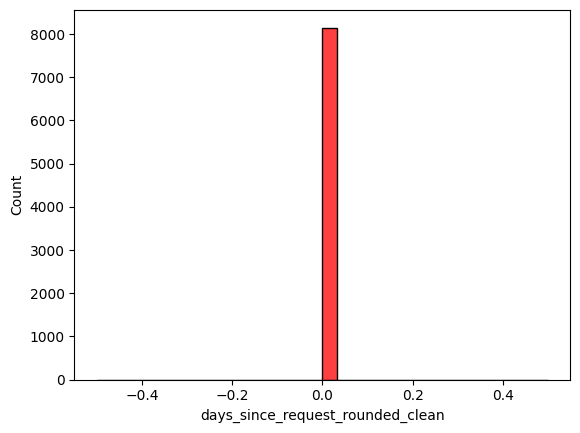

In [52]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['days_since_request_rounded_clean'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['days_since_request_rounded_clean'], bins=30, color='red')
plt.show()

In [53]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 0]['days_since_request_rounded_clean'].value_counts().head(5)
print(top_5)

days_since_request_rounded_clean
0.0    786838
Name: count, dtype: int64


In [54]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 1]['days_since_request_rounded_clean'].value_counts().head(5)
print(top_5)

days_since_request_rounded_clean
0.0    8151
Name: count, dtype: int64


In [55]:
#дисперсия становится = 0 -> удяляем переменную
df_train_test = df_train_test.drop('days_since_request_rounded_clean', axis = 1)
df_train_test = df_train_test.drop('days_since_request_rounded', axis = 1)
df_train_test = df_train_test.drop('days_since_request', axis = 1)

### intended_balcon_amount
Мы знаем, что все отрицательное это пустышки

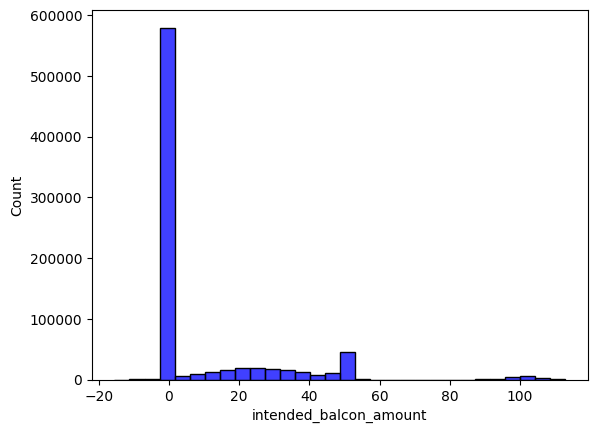

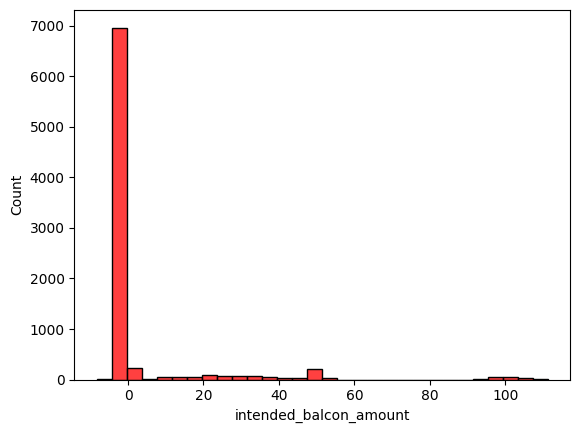

In [56]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['intended_balcon_amount'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['intended_balcon_amount'], bins=30, color='red')
plt.show()

In [57]:
(df_train_test[df_train_test['fraud_bool'] == 0]['intended_balcon_amount'] < 0).sum()

np.int64(578748)

In [58]:
578748/786838

0.7355364128321205

In [59]:
(df_train_test[df_train_test['fraud_bool'] == 1]['intended_balcon_amount'] < 0).sum()

np.int64(7160)

In [60]:
7160/8151

0.8784198257882468

In [61]:
df_train_test['intended_balcon_amount'] = df_train_test['intended_balcon_amount'].where(df_train_test['intended_balcon_amount'] >= 0, np.nan)

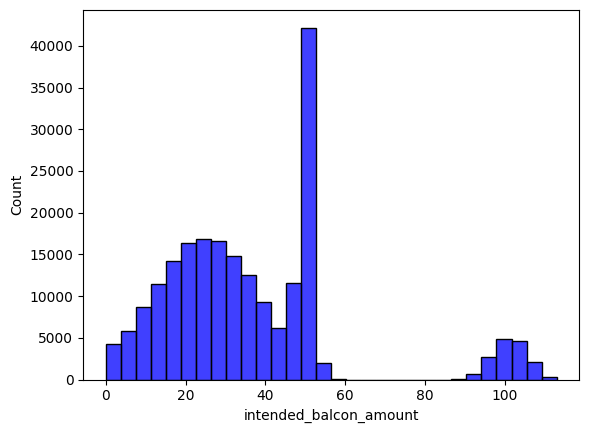

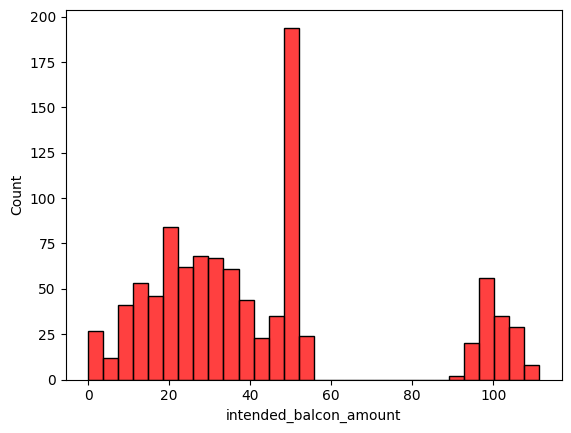

In [62]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['intended_balcon_amount'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['intended_balcon_amount'], bins=30, color='red')
plt.show()

In [63]:
#отчетливо видим 2 горба - бимодальное распределение. Поэтому тут выбросы пока искать не будем. Оба горба достаточно гладкие

### zip_count_4w

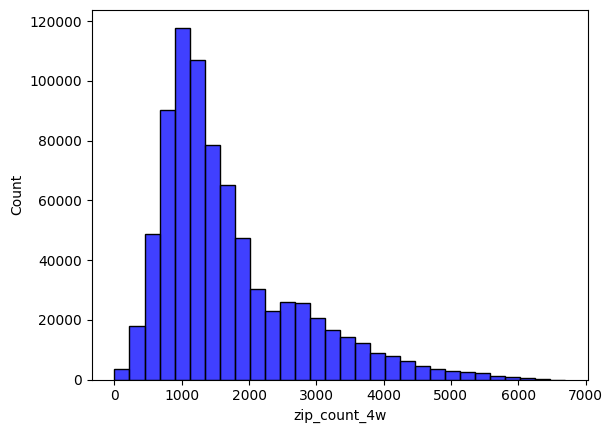

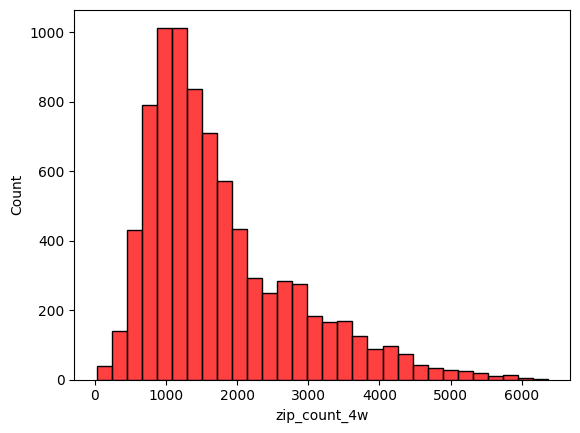

In [64]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['zip_count_4w'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['zip_count_4w'], bins=30, color='red')
plt.show()

In [65]:
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'zip_count_4w')
print(f'Выбросы по zip_count_4w NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'zip_count_4w')
print(f'Выбросы по zip_count_4w fraud: {len(outl)}')

Выбросы по zip_count_4w NOT fraud: 41871
Выбросы по zip_count_4w fraud: 332


In [66]:
41871/786838

0.0532142575727151

In [67]:
332/8151

0.040731198625935466

In [68]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['zip_count_4w'].quantile(0.25)
Q3 = df_nonF['zip_count_4w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['zip_count_4w'] >= lower_bound) & (df_nonF['zip_count_4w'] <= upper_bound)]['zip_count_4w']

median_value_nonF = non_outliers.median()

df_nonF['zip_count_4w_clean'] = np.where(
    (df_nonF['zip_count_4w'] < lower_bound) | (df_nonF['zip_count_4w'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['zip_count_4w']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['zip_count_4w'].quantile(0.25)
Q3 = df_F['zip_count_4w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['zip_count_4w'] >= lower_bound) & (df_F['zip_count_4w'] <= upper_bound)]['zip_count_4w']

median_value_F = non_outliers.median()

df_F['zip_count_4w_clean'] = np.where(
    (df_F['zip_count_4w'] < lower_bound) | (df_F['zip_count_4w'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['zip_count_4w']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/2115661605.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['zip_count_4w_clean'] = np.where(
/tmp/ipykernel_16174/2115661605.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['zip_count_4w_clean'] = np.where(


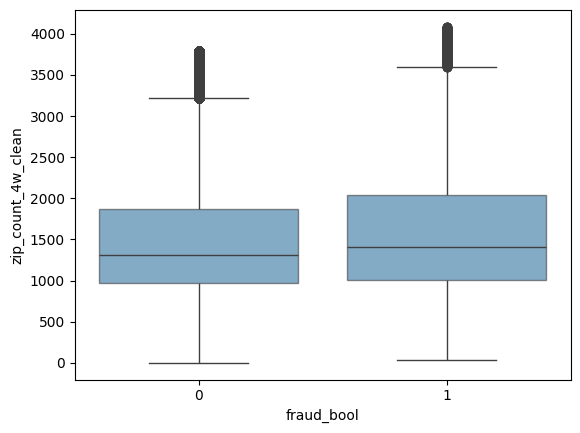

In [69]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='zip_count_4w_clean', boxprops=dict(alpha=.6))
plt.show()

### velocity_6h
Velocity of total applications made in last 6 hours i.e., average number of applications per hour in the last 6 hours. Ranges between [−211, 24763].

по смысле не может быть отрицательным. Мы явно этого не знаем, но предположим, что также отрицательные значения - пустышки

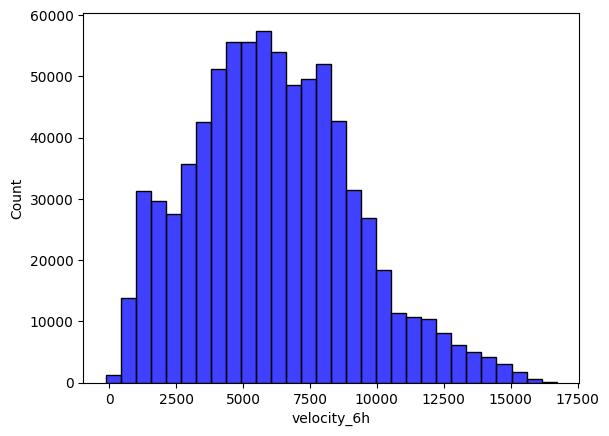

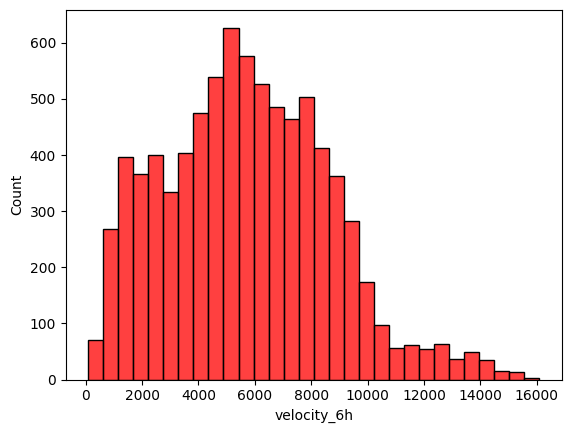

In [70]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['velocity_6h'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['velocity_6h'], bins=30, color='red')
plt.show()

In [71]:
(df_train_test[df_train_test['fraud_bool'] == 0]['velocity_6h'] < 0).sum()

np.int64(20)

In [72]:
(df_train_test[df_train_test['fraud_bool'] == 1]['velocity_6h'] < 0).sum()

np.int64(0)

In [78]:
df_train_test['velocity_6h'] = df_train_test['velocity_6h'].where(
    df_train_test['velocity_6h'] >= 0, np.nan
)

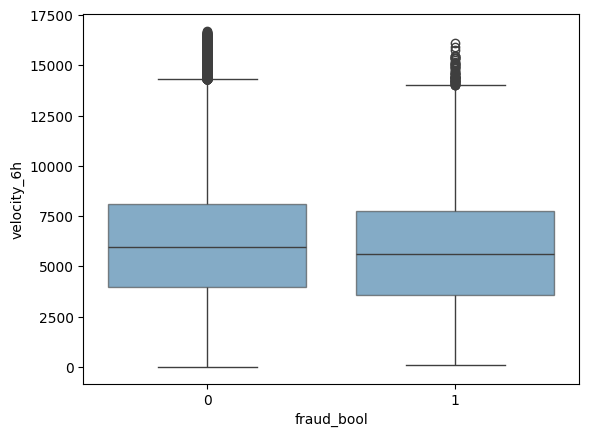

In [79]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='velocity_6h', boxprops=dict(alpha=.6))
plt.show()

In [80]:
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'velocity_6h')
print(f'Выбросы по velocity_6h NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'velocity_6h')
print(f'Выбросы по velocity_6h fraud: {len(outl)}')

Выбросы по velocity_6h NOT fraud: 6426
Выбросы по velocity_6h fraud: 60


In [81]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['velocity_6h'].quantile(0.25)
Q3 = df_nonF['velocity_6h'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['velocity_6h'] >= lower_bound) & (df_nonF['velocity_6h'] <= upper_bound)]['velocity_6h']

median_value_nonF = non_outliers.median()

df_nonF['velocity_6h_clean'] = np.where(
    (df_nonF['velocity_6h'] < lower_bound) | (df_nonF['velocity_6h'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['velocity_6h']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['velocity_6h'].quantile(0.25)
Q3 = df_F['velocity_6h'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['velocity_6h'] >= lower_bound) & (df_F['velocity_6h'] <= upper_bound)]['velocity_6h']

median_value_F = non_outliers.median()

df_F['velocity_6h_clean'] = np.where(
    (df_F['velocity_6h'] < lower_bound) | (df_F['velocity_6h'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['velocity_6h']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/3271829055.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['velocity_6h_clean'] = np.where(
/tmp/ipykernel_16174/3271829055.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['velocity_6h_clean'] = np.where(


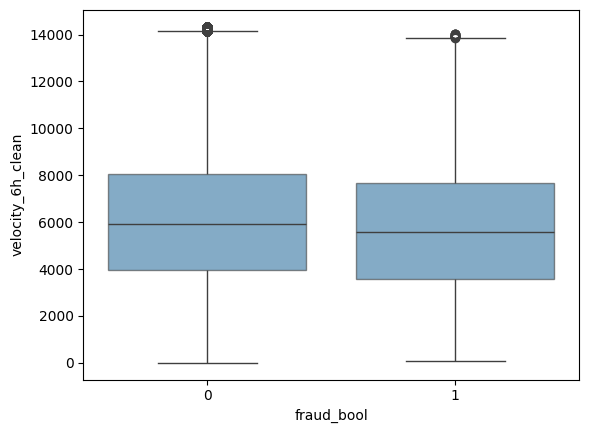

In [82]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='velocity_6h_clean', boxprops=dict(alpha=.6))
plt.show()

### velocity_24h

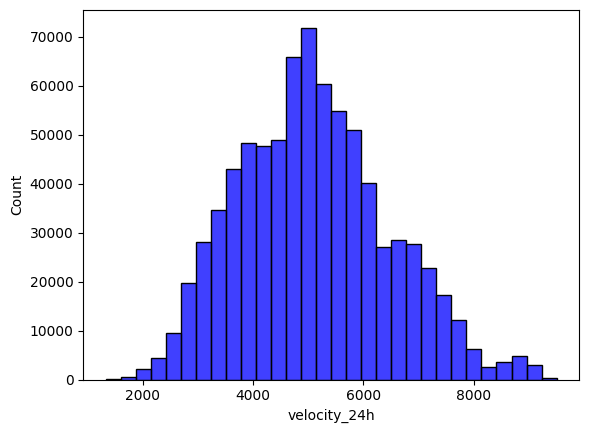

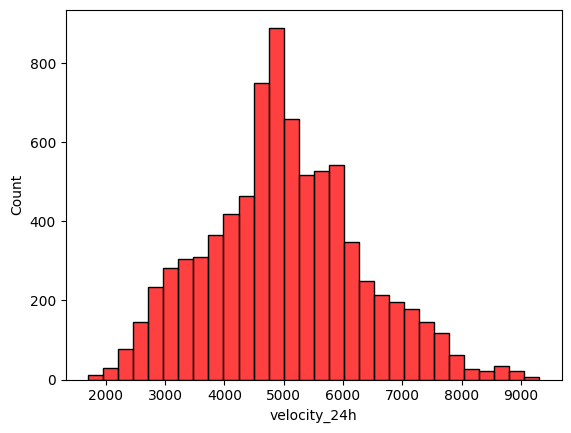

In [83]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['velocity_24h'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['velocity_24h'], bins=30, color='red')
plt.show()

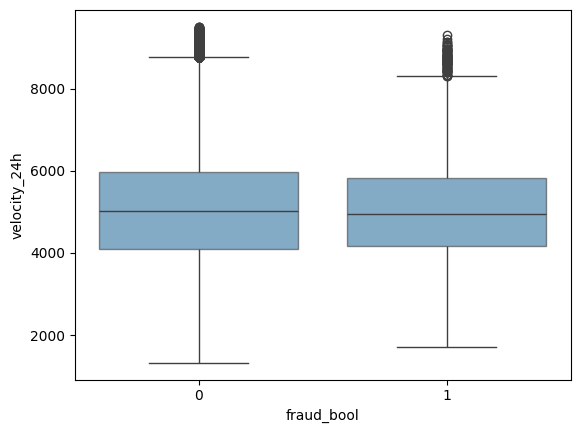

In [84]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='velocity_24h', boxprops=dict(alpha=.6))
plt.show()

In [85]:
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'velocity_24h')
print(f'Выбросы по velocity_6h NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'velocity_24h')
print(f'Выбросы по velocity_6h fraud: {len(outl)}')

Выбросы по velocity_6h NOT fraud: 6846
Выбросы по velocity_6h fraud: 84


In [86]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['velocity_24h'].quantile(0.25)
Q3 = df_nonF['velocity_24h'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['velocity_24h'] >= lower_bound) & (df_nonF['velocity_24h'] <= upper_bound)]['velocity_24h']

median_value_nonF = non_outliers.median()

df_nonF['velocity_24h_clean'] = np.where(
    (df_nonF['velocity_24h'] < lower_bound) | (df_nonF['velocity_24h'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['velocity_24h']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['velocity_24h'].quantile(0.25)
Q3 = df_F['velocity_24h'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['velocity_24h'] >= lower_bound) & (df_F['velocity_24h'] <= upper_bound)]['velocity_24h']

median_value_F = non_outliers.median()

df_F['velocity_24h_clean'] = np.where(
    (df_F['velocity_24h'] < lower_bound) | (df_F['velocity_24h'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['velocity_24h']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/476040887.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['velocity_24h_clean'] = np.where(
/tmp/ipykernel_16174/476040887.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['velocity_24h_clean'] = np.where(


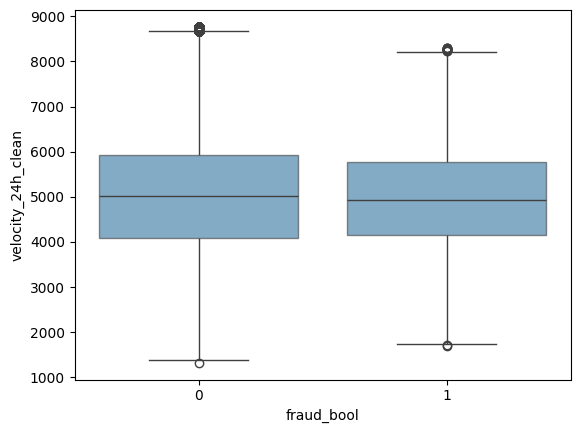

In [87]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='velocity_24h_clean', boxprops=dict(alpha=.6))
plt.show()

### bank_branch_count_8w

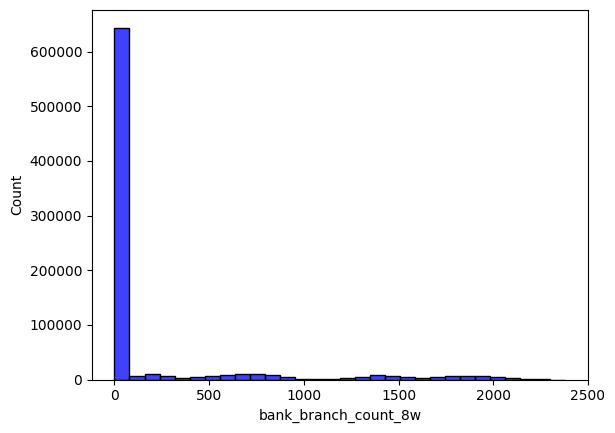

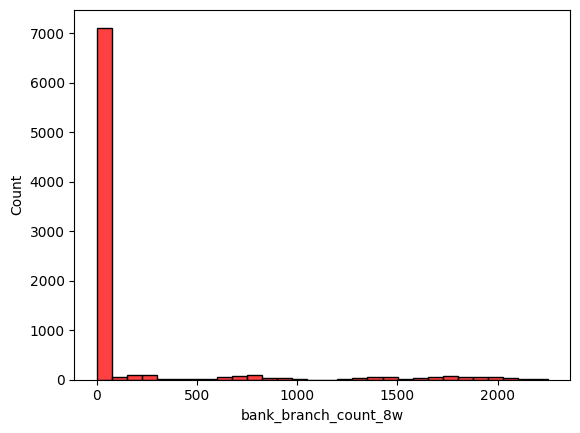

In [88]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['bank_branch_count_8w'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['bank_branch_count_8w'], bins=30, color='red')
plt.show()

In [89]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 0]['bank_branch_count_8w'].value_counts().head(5)
print(top_5)

bank_branch_count_8w
1     116577
0     112274
2      45510
11     23377
10     23074
Name: count, dtype: int64


In [90]:
top_5 = df_train_test[df_train_test['fraud_bool'] == 1]['bank_branch_count_8w'].value_counts().head(5)
print(top_5)

bank_branch_count_8w
0     1914
1     1771
2      540
10     208
11     207
Name: count, dtype: int64


In [91]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'bank_branch_count_8w')
print(f'Выбросы по bank_branch_count_8w NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'bank_branch_count_8w')
print(f'Выбросы по bank_branch_count_8w fraud: {len(outl)}')

Выбросы по bank_branch_count_8w NOT fraud: 143329
Выбросы по bank_branch_count_8w fraud: 1234


In [92]:
143329/786838

0.18215820791573362

In [93]:
1234/8151

0.15139246718194085

In [94]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['bank_branch_count_8w'].quantile(0.25)
Q3 = df_nonF['bank_branch_count_8w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['bank_branch_count_8w'] >= lower_bound) & (df_nonF['bank_branch_count_8w'] <= upper_bound)]['bank_branch_count_8w']

median_value_nonF = non_outliers.median()

df_nonF['bank_branch_count_8w_clean'] = np.where(
    (df_nonF['bank_branch_count_8w'] < lower_bound) | (df_nonF['bank_branch_count_8w'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['bank_branch_count_8w']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['bank_branch_count_8w'].quantile(0.25)
Q3 = df_F['bank_branch_count_8w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['bank_branch_count_8w'] >= lower_bound) & (df_F['bank_branch_count_8w'] <= upper_bound)]['bank_branch_count_8w']

median_value_F = non_outliers.median()

df_F['bank_branch_count_8w_clean'] = np.where(
    (df_F['bank_branch_count_8w'] < lower_bound) | (df_F['bank_branch_count_8w'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['bank_branch_count_8w']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/1551300091.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['bank_branch_count_8w_clean'] = np.where(
/tmp/ipykernel_16174/1551300091.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['bank_branch_count_8w_clean'] = np.where(


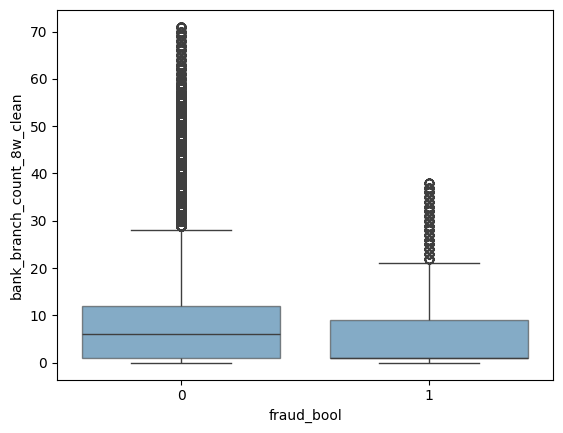

In [95]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='bank_branch_count_8w_clean', boxprops=dict(alpha=.6))
plt.show()

In [96]:
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'bank_branch_count_8w_clean')
print(f'Выбросы по bank_branch_count_8w NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'bank_branch_count_8w_clean')
print(f'Выбросы по bank_branch_count_8w fraud: {len(outl)}')

Выбросы по bank_branch_count_8w NOT fraud: 55035
Выбросы по bank_branch_count_8w fraud: 378


### date_of_birth_distinct_emails_4w

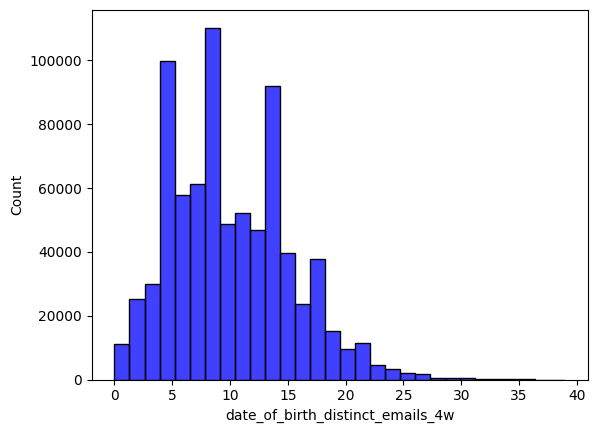

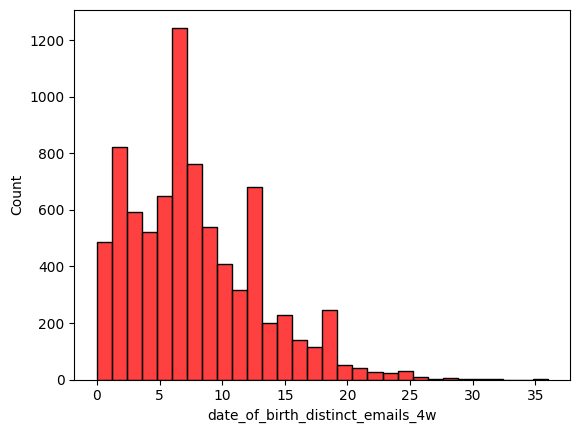

In [97]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['date_of_birth_distinct_emails_4w'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['date_of_birth_distinct_emails_4w'], bins=30, color='red')
plt.show()

In [98]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'date_of_birth_distinct_emails_4w')
print(f'Выбросы по date_of_birth_distinct_emails_4w NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'date_of_birth_distinct_emails_4w')
print(f'Выбросы по date_of_birth_distinct_emails_4w fraud: {len(outl)}')

Выбросы по date_of_birth_distinct_emails_4w NOT fraud: 9147
Выбросы по date_of_birth_distinct_emails_4w fraud: 107


In [99]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['date_of_birth_distinct_emails_4w'].quantile(0.25)
Q3 = df_nonF['date_of_birth_distinct_emails_4w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['date_of_birth_distinct_emails_4w'] >= lower_bound)
                        & (df_nonF['date_of_birth_distinct_emails_4w'] <= upper_bound)]['date_of_birth_distinct_emails_4w']

median_value_nonF = non_outliers.median()

df_nonF['date_of_birth_distinct_emails_4w_clean'] = np.where(
    (df_nonF['date_of_birth_distinct_emails_4w'] < lower_bound) | (df_nonF['date_of_birth_distinct_emails_4w'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['date_of_birth_distinct_emails_4w']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['date_of_birth_distinct_emails_4w'].quantile(0.25)
Q3 = df_F['date_of_birth_distinct_emails_4w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['date_of_birth_distinct_emails_4w'] >= lower_bound)
                      & (df_F['date_of_birth_distinct_emails_4w'] <= upper_bound)]['date_of_birth_distinct_emails_4w']

median_value_F = non_outliers.median()

df_F['date_of_birth_distinct_emails_4w_clean'] = np.where(
    (df_F['date_of_birth_distinct_emails_4w'] < lower_bound) | (df_F['date_of_birth_distinct_emails_4w'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['date_of_birth_distinct_emails_4w']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/3288320785.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['date_of_birth_distinct_emails_4w_clean'] = np.where(
/tmp/ipykernel_16174/3288320785.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['date_of_birth_distinct_emails_4w_clean'] = np.where(


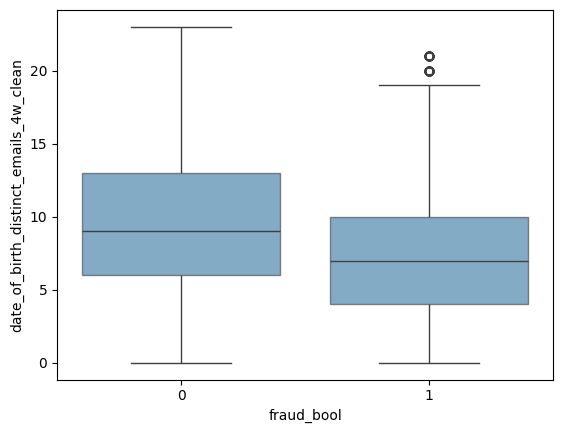

In [100]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='date_of_birth_distinct_emails_4w_clean', boxprops=dict(alpha=.6))
plt.show()

### credit_risk_score
мы не знаем, какая шкала применена -> не понимаем, нормальны ли отрицательные значения.
Т к их довольно много разнообразных - предположим, что они нормальны

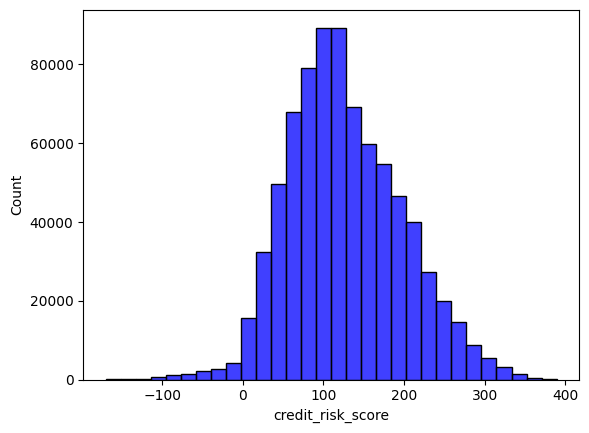

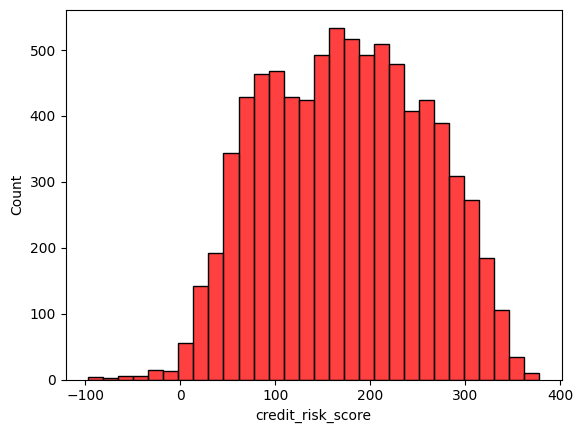

In [101]:
sns.histplot(df_train_test[df_train_test['fraud_bool'] == 0]['credit_risk_score'], bins=30, color='blue')
plt.show()

sns.histplot(df_train_test[df_train_test['fraud_bool'] == 1]['credit_risk_score'], bins=30, color='red')
plt.show()

In [102]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 0], 'credit_risk_score')
print(f'Выбросы по credit_risk_score NOT fraud: {len(outl)}')

outl = find_outliers(df_train_test[df_train_test['fraud_bool'] == 1], 'credit_risk_score')
print(f'Выбросы по credit_risk_score fraud: {len(outl)}')

Выбросы по credit_risk_score NOT fraud: 6645
Выбросы по credit_risk_score fraud: 1


In [103]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

#медиана для не фрода
df_nonF = df_train_test[df_train_test['fraud_bool'] == 0]

Q1 = df_nonF['credit_risk_score'].quantile(0.25)
Q3 = df_nonF['credit_risk_score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_nonF[(df_nonF['credit_risk_score'] >= lower_bound)
                        & (df_nonF['credit_risk_score'] <= upper_bound)]['credit_risk_score']

median_value_nonF = non_outliers.median()

df_nonF['credit_risk_score_clean'] = np.where(
    (df_nonF['credit_risk_score'] < lower_bound) | (df_nonF['credit_risk_score'] > upper_bound),  # Условие
    median_value_nonF,                                                 # Замена на медиану
    df_nonF['credit_risk_score']                                                  # Иначе оставить как есть
)

#медиана для фрода
df_F = df_train_test[df_train_test['fraud_bool'] == 1]

Q1 = df_F['credit_risk_score'].quantile(0.25)
Q3 = df_F['credit_risk_score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_F[(df_F['credit_risk_score'] >= lower_bound)
                      & (df_F['credit_risk_score'] <= upper_bound)]['credit_risk_score']

median_value_F = non_outliers.median()

df_F['credit_risk_score_clean'] = np.where(
    (df_F['credit_risk_score'] < lower_bound) | (df_F['credit_risk_score'] > upper_bound),  # Условие
    median_value_F,                                                                                         # Замена на медиану
    df_F['credit_risk_score']                                                                       # Иначе оставить как есть
)

df_train_test = pd.concat([df_nonF, df_F], ignore_index=True)

/tmp/ipykernel_16174/481439946.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonF['credit_risk_score_clean'] = np.where(
/tmp/ipykernel_16174/481439946.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_F['credit_risk_score_clean'] = np.where(


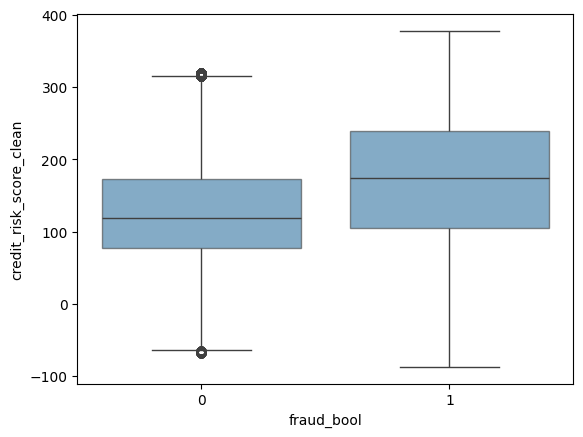

In [104]:
sns.boxplot(data=df_train_test, x='fraud_bool', y='credit_risk_score_clean', boxprops=dict(alpha=.6))
plt.show()

## Анализ и подбор переменных

### Шаг 1 экспертный отбор

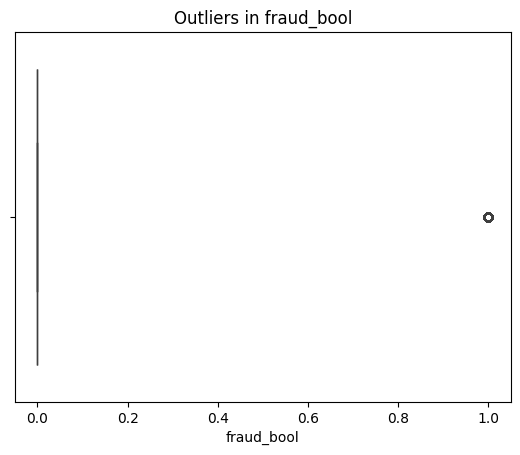

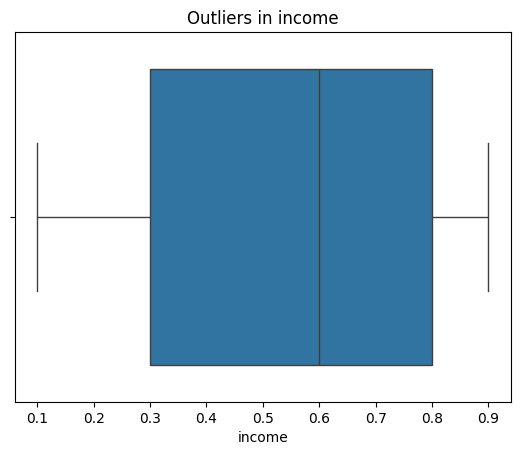

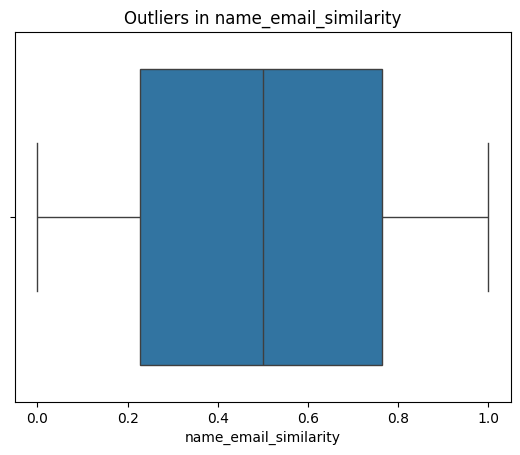

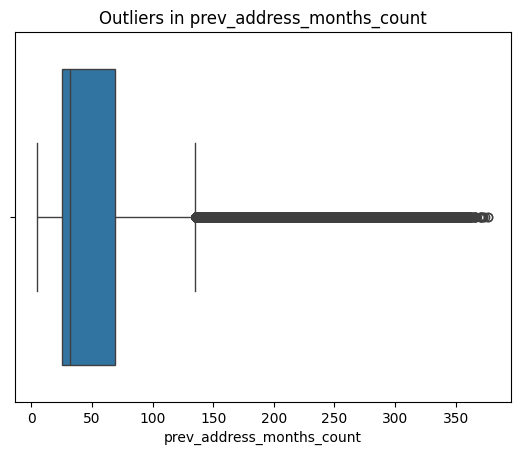

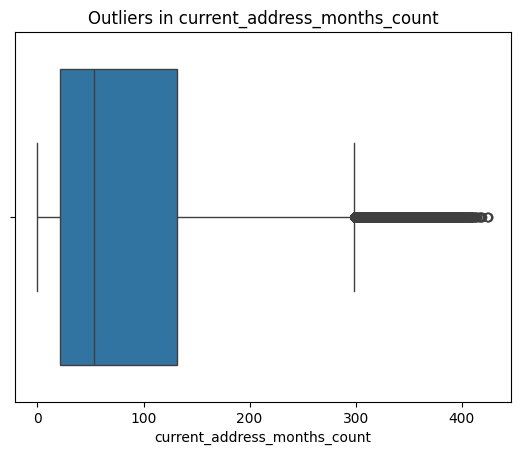

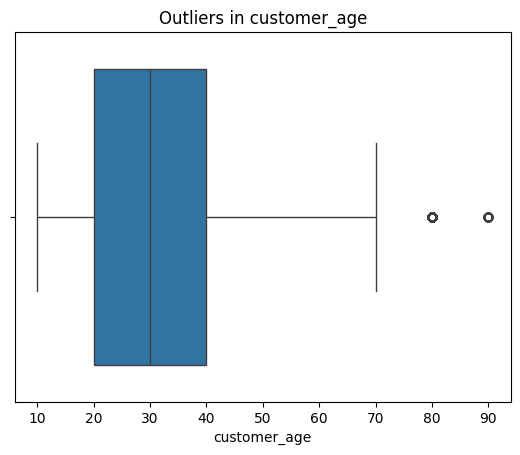

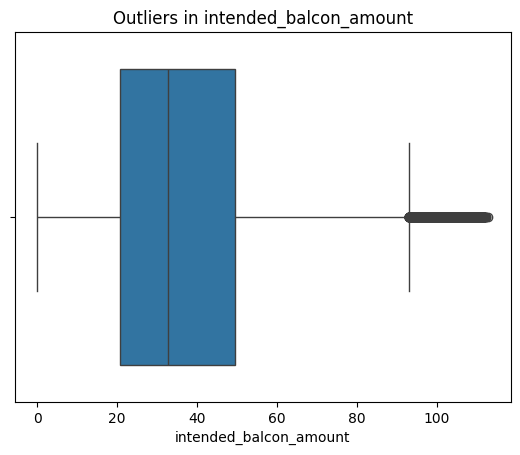

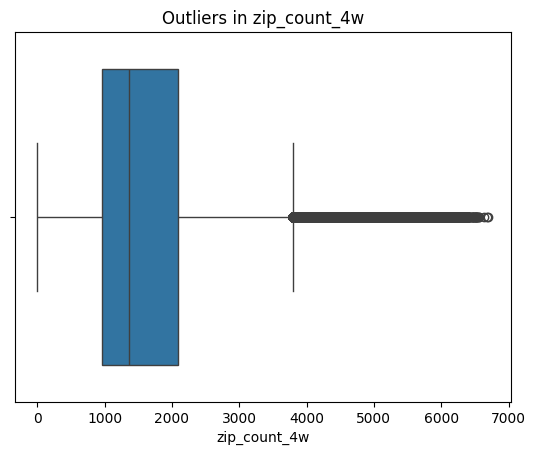

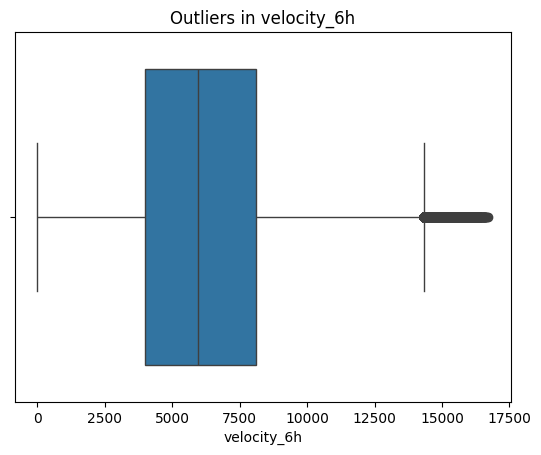

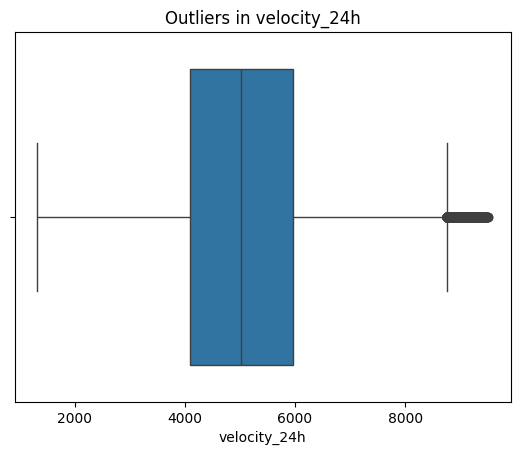

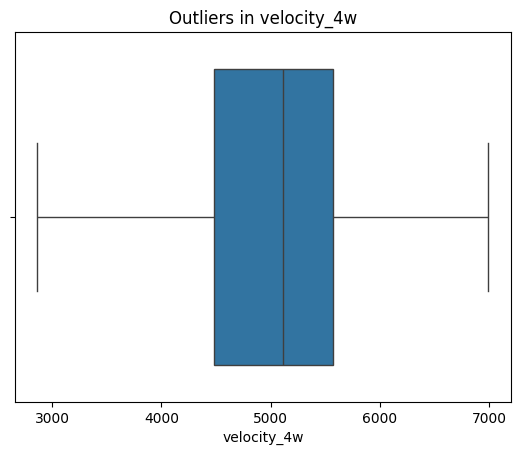

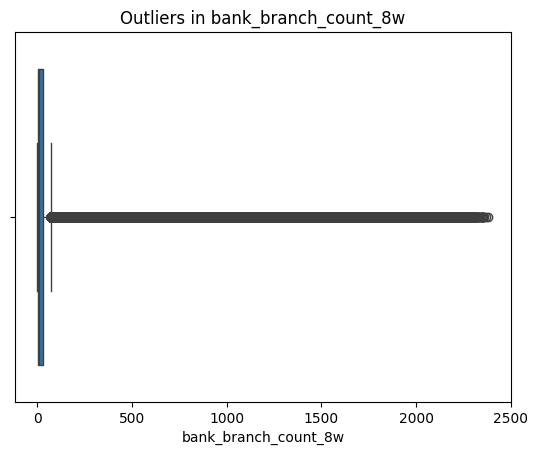

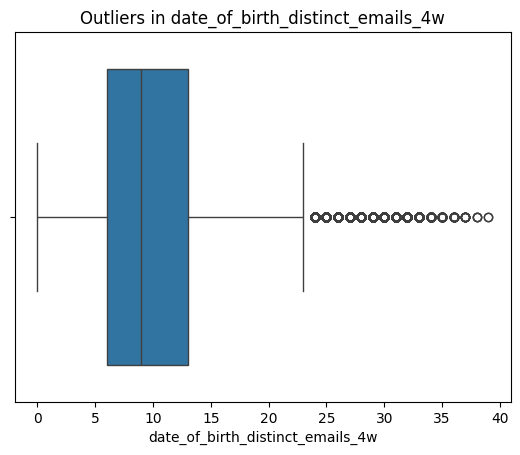

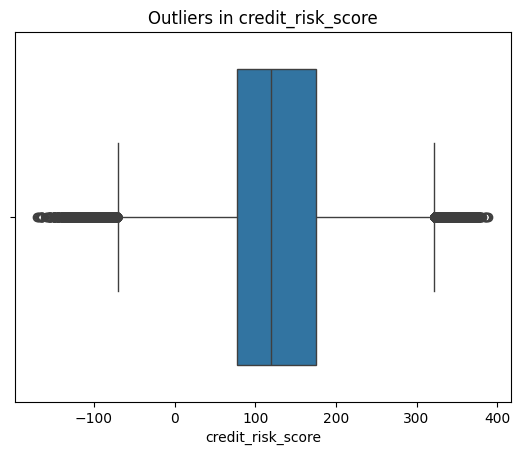

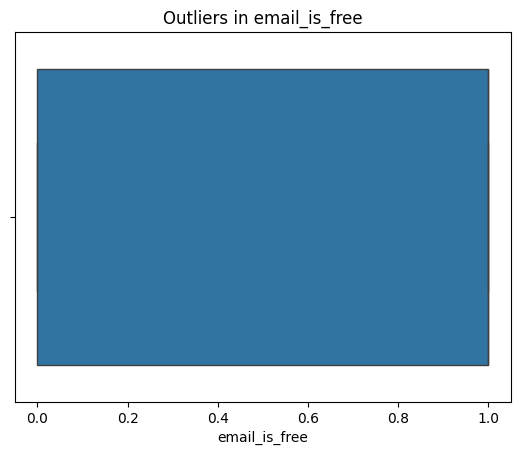

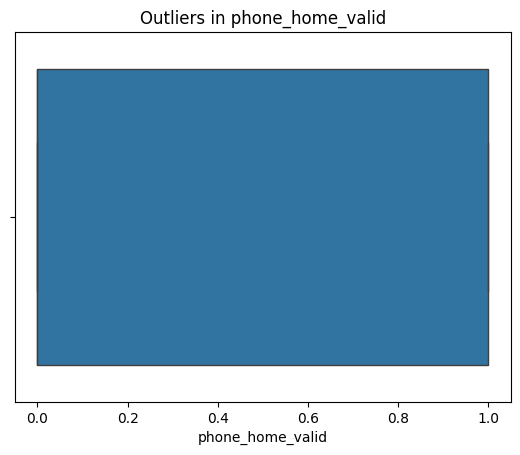

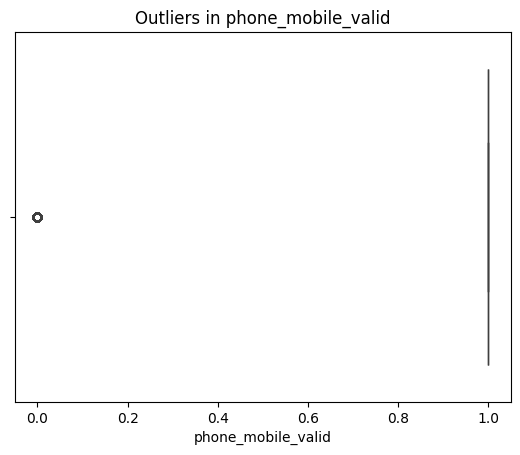

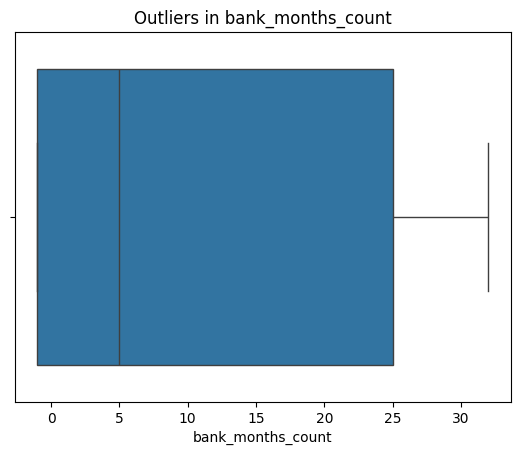

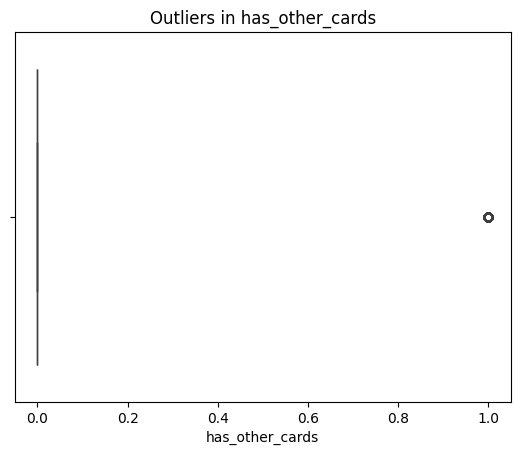

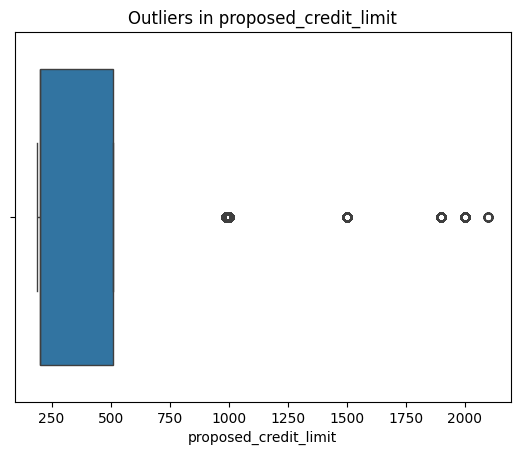

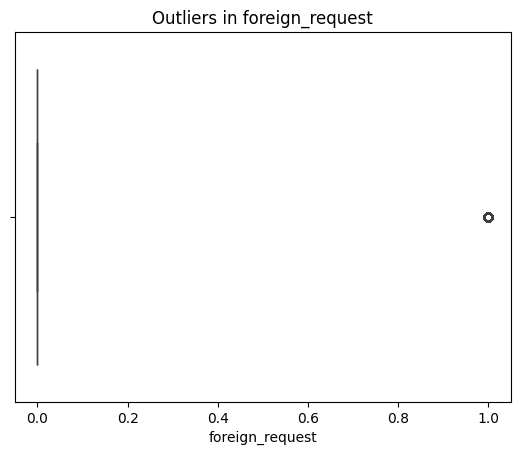

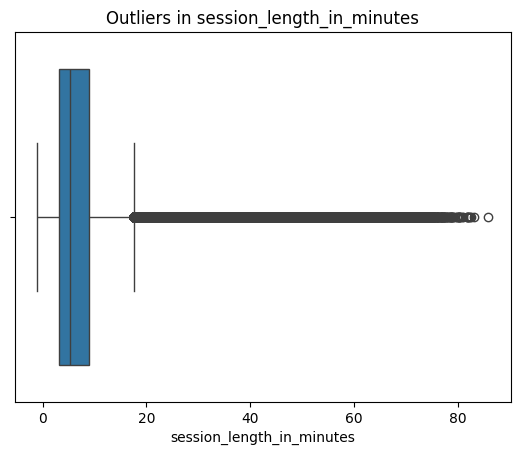

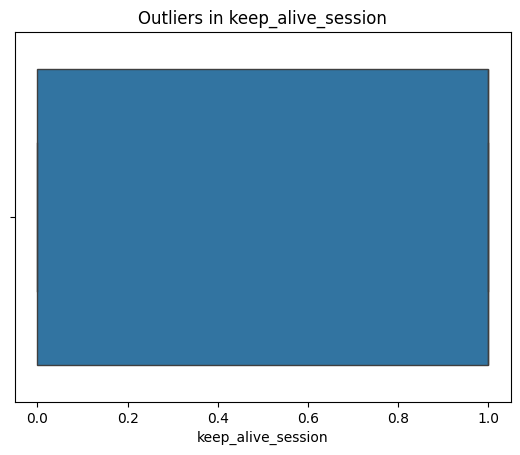

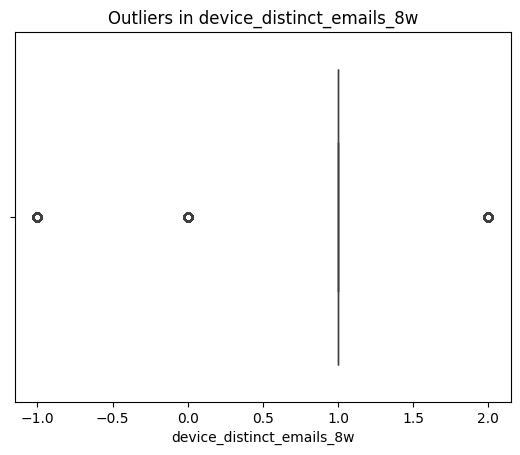

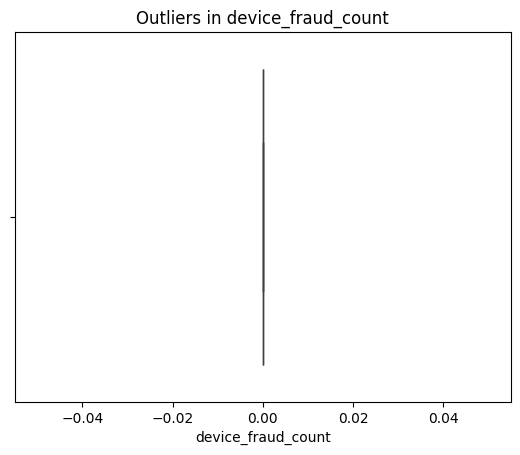

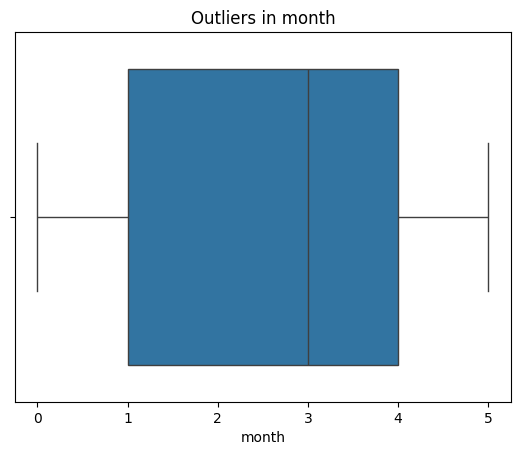

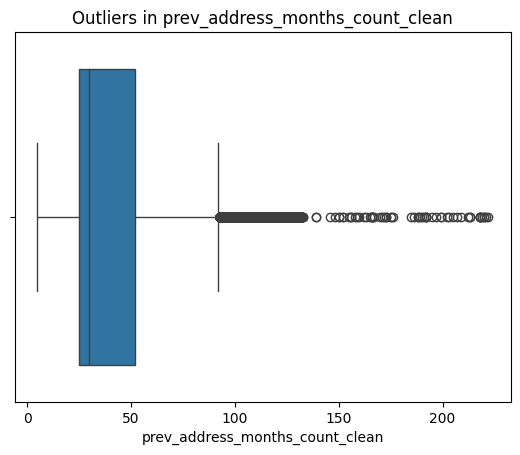

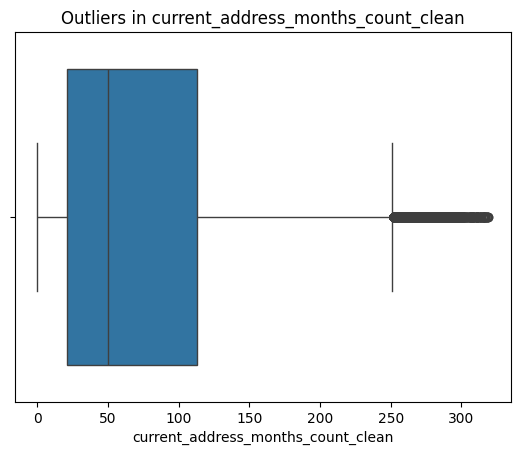

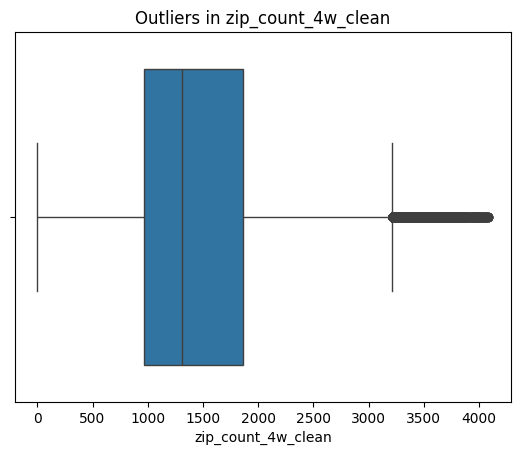

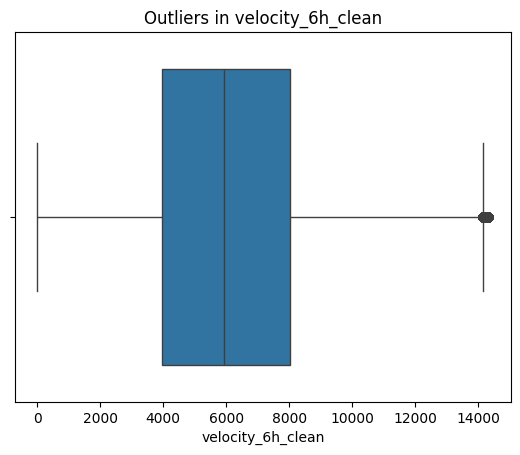

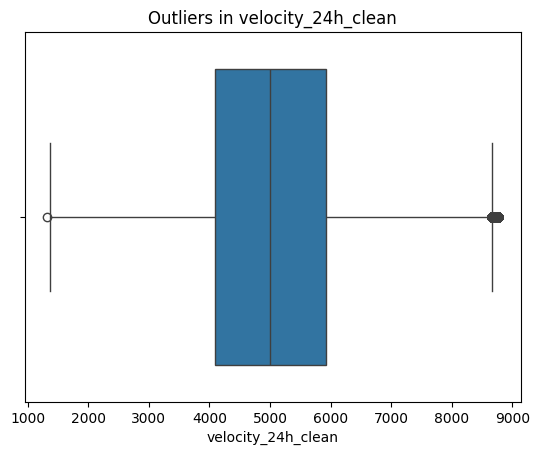

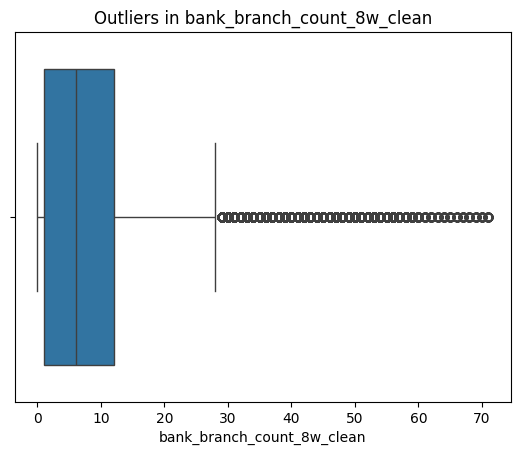

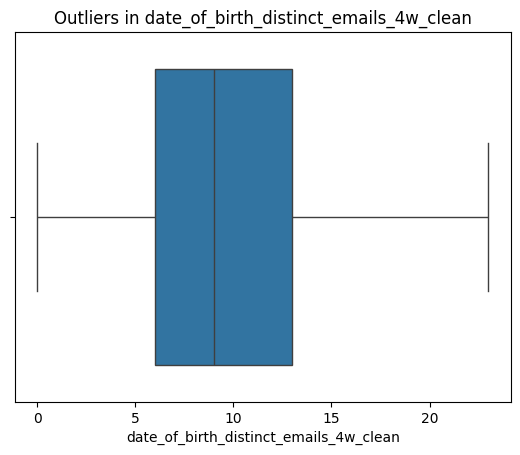

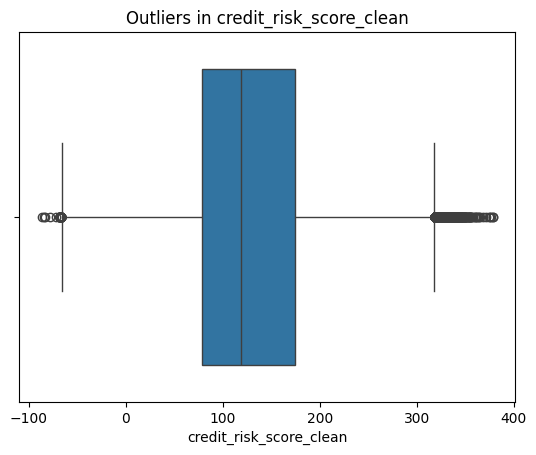

In [105]:
#экспертный отбор признаков.
#Уберем признаки с большим числом не заполненных значений и нестабильным распределением
#для анализа используем трайн-тест часть

#посмотрим числовые переменные
#посмотрим на графики, предположим, где могут быть незаполеннные и нестабильные переменные
num_columns = list(df_train_test.select_dtypes(include=['float64', 'int64']).columns)

for col in num_columns:
    sns.boxplot(x=df_train_test[col])
    plt.title(f"Outliers in {col}")
    plt.show()

#претенденты на удаление:
# prev_address_months_count - Number of months in previous registered address of the applicant, i.e. the applicant’s previous residence, if applicable.
#   Ranges between [−1, 380] months (-1 is a missing value) По всей видиммости слишком много незаполненных
# days_since_request - Number of days passed since application was done. Ranges between [0, 78] days. Очень много выбросов, требует как минимум очистки
# intended_balcon_amount - Initial transferred amount for application. Ranges between [−1, 108]
#   присутствуют отрицательные значения, даже вне рейнджа заявленного составителем датасета
# zip_count_4w - Number of applications within same zip code in last 4 weeks. Ranges between [1, 5767] возможно 2 горба, и нет так много выбросов
# bank_branch_count_8w - Number of total applications in the selected bank branch in last 8 weeks. Ranges between [0, 2521]
#   много выбросов, мало нормальных значений. но вообще непонятно, может они как раз и есть подозрительные - несбалансированные данные ж
# device_distinct_emails_8w - есть отроицательные значения, которых быть не должно
# device_fraud_count - все нули, не имеет смысла
#
#
# Глобальный вопрос - стоит ли выбрасывать выбросы? т к выборка не сбалансированная, возмонжо наши выбросы, это и есть показатели фрода
####

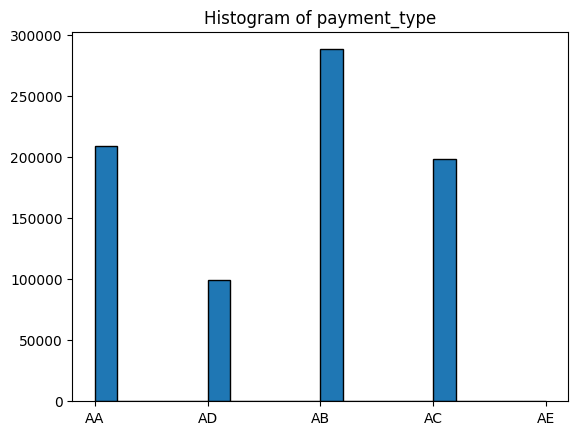

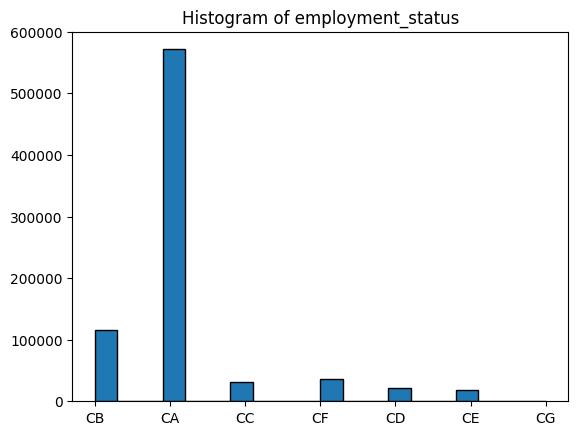

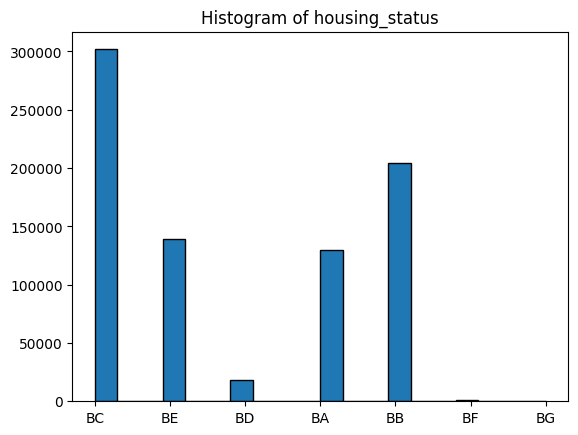

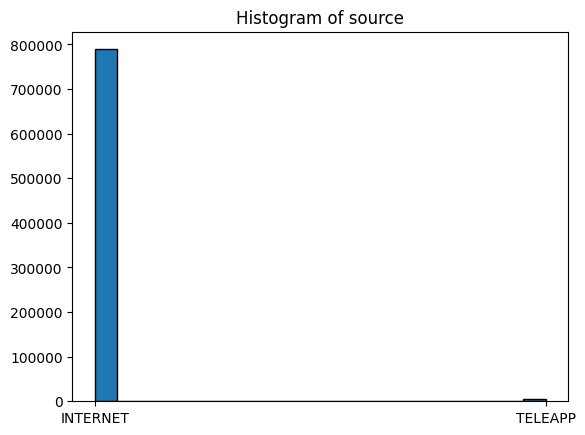

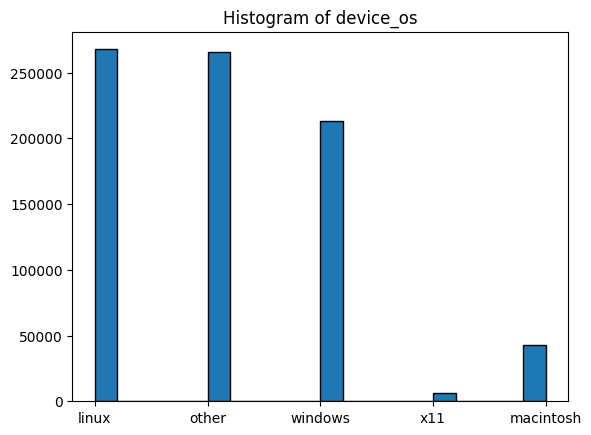

In [106]:
#Посмотрим категориальные переменные на гистограммах

num_columns = list(df_train_test.select_dtypes(include=['object']).columns)

for col in num_columns:
    plt.hist(df_train_test[col], bins = 20, edgecolor = 'k')
    plt.title(f"Histogram of {col}")
    plt.show()

# претенденты на доп анализ:
# payment_type - очень мало категории AE
# source - будто все internet
# device_os - очень мало значений в категории x11
####

In [107]:
df_train_test[['device_fraud_count']].describe() # точно выбрасываем, совсем не меняется

,device_fraud_count
count,794989.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [108]:
df_train_test[['source']].describe() #интернета менее 1 процента, но может это и показатель?

,source
count,794989
unique,2
top,INTERNET
freq,789252


In [109]:
794989-789252

5737

In [110]:
5737/794989

0.00721645205153782

In [111]:
df_train_test = df_train_test.drop('device_fraud_count', axis = 1)
df_train_test

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,...,device_distinct_emails_8w,month,prev_address_months_count_clean,current_address_months_count_clean,zip_count_4w_clean,velocity_6h_clean,velocity_24h_clean,bank_branch_count_8w_clean,date_of_birth_distinct_emails_4w_clean,credit_risk_score_clean
0,0,0.3,0.986506,NaN,25.0,40,102.453711,AA,1059,13096.035018,...,1,0,NaN,25.0,1059.0,13096.035018,7850.955007,5.0,5.0,163.0
1,0,0.8,0.617426,NaN,89.0,20,NaN,AD,1658,9223.283431,...,1,0,NaN,89.0,1658.0,9223.283431,5745.251481,3.0,18.0,154.0
2,0,0.8,0.996707,9.0,14.0,40,NaN,AB,1095,4471.472149,...,1,0,9.0,14.0,1095.0,4471.472149,5471.988958,15.0,11.0,89.0
3,0,0.6,0.475100,11.0,14.0,30,NaN,AB,3483,14431.993621,...,1,0,11.0,14.0,3483.0,5933.866552,6755.344479,11.0,13.0,90.0
4,0,0.9,0.842307,NaN,29.0,40,47.152498,AA,2339,7601.511579,...,1,0,NaN,29.0,2339.0,7601.511579,5124.046930,1.0,6.0,91.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794984,1,0.1,0.595063,NaN,41.0,30,NaN,AC,173,8748.840025,...,1,5,NaN,41.0,173.0,8748.840025,5523.209531,0.0,6.0,287.0
794985,1,0.9,0.302105,NaN,190.0,60,NaN,AC,903,6376.849688,...,1,5,NaN,190.0,903.0,6376.849688,4475.932550,1.0,3.0,257.0
794986,1,0.7,0.278439,NaN,97.0,50,NaN,AC,900,5872.242985,...,1,5,NaN,97.0,900.0,5872.242985,4561.157245,1.0,2.0,256.0
794987,1,0.9,0.337855,NaN,135.0,60,NaN,AC,849,3974.154245,...,1,5,NaN,135.0,849.0,3974.154245,2939.083398,0.0,6.0,261.0


### Шаг 2 Джини

In [112]:
#Сделаем дамми переменные из категориальных букв
num_columns = list(df_train_test.select_dtypes(include=['object']).columns)

for col in num_columns:
    dummies = pd.get_dummies(df_train_test[col], prefix=col)
    df_train_test = pd.concat([df_train_test, dummies], axis=1)

df_train_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794989 entries, 0 to 794988
Data columns (total 64 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   fraud_bool                              794989 non-null  int64  
 1   income                                  794989 non-null  float64
 2   name_email_similarity                   794989 non-null  float64
 3   prev_address_months_count               226566 non-null  float64
 4   current_address_months_count            791962 non-null  float64
 5   customer_age                            794989 non-null  int64  
 6   intended_balcon_amount                  209081 non-null  float64
 7   payment_type                            794989 non-null  object 
 8   zip_count_4w                            794989 non-null  int64  
 9   velocity_6h                             794969 non-null  float64
 10  velocity_24h                            7949

In [113]:
#Разделим на тест и трейн выборку
X = df_train_test.select_dtypes(include=['float64', 'int64', 'bool']).drop(columns = ['fraud_bool'])
y = df_train_test['fraud_bool']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [115]:
# Посмотрим джини на дереве-классификаторе.

# Допустим, X — матрица признаков, y — целевая переменная
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=1208)

In [116]:
#Gini importance с train — используем для отбора признаков
gini_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Gini_train': model.feature_importances_
}).sort_values('Gini_train', ascending=False)

# Выводим все признаки
print(gini_importance)

                                   Feature  Gini_train
10                    bank_branch_count_8w    0.083712
31                 credit_risk_score_clean    0.064361
26                      zip_count_4w_clean    0.055097
1                    name_email_similarity    0.052809
25      current_address_months_count_clean    0.046298
9                              velocity_4w    0.046296
6                             zip_count_4w    0.043958
7                              velocity_6h    0.043824
20               session_length_in_minutes    0.043752
3             current_address_months_count    0.042564
8                             velocity_24h    0.042267
27                       velocity_6h_clean    0.042152
28                      velocity_24h_clean    0.041152
12                       credit_risk_score    0.039850
29              bank_branch_count_8w_clean    0.039605
11        date_of_birth_distinct_emails_4w    0.025260
30  date_of_birth_distinct_emails_4w_clean    0.024336
16        

In [117]:
# проверяем стабильность на test через permutation importance
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=SEED,
    scoring='roc_auc'
)

In [118]:
perm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Perm_test_mean': perm.importances_mean,
    'Perm_test_std':  perm.importances_std
}).sort_values('Perm_test_mean', ascending=False)

In [119]:
importance_combined = gini_importance.merge(perm_importance, on='Feature')

print(importance_combined.head(20).to_string(index=False))

                               Feature  Gini_train  Perm_test_mean  Perm_test_std
                  bank_branch_count_8w    0.083712        0.072433       0.001635
               credit_risk_score_clean    0.064361        0.000355       0.001339
                    zip_count_4w_clean    0.055097        0.006591       0.002705
                 name_email_similarity    0.052809        0.011650       0.002562
    current_address_months_count_clean    0.046298        0.012233       0.001551
                           velocity_4w    0.046296        0.001278       0.001199
                          zip_count_4w    0.043958        0.004036       0.001029
                           velocity_6h    0.043824        0.012565       0.001768
             session_length_in_minutes    0.043752        0.001540       0.000990
          current_address_months_count    0.042564        0.004643       0.001969
                          velocity_24h    0.042267        0.010972       0.001723
                

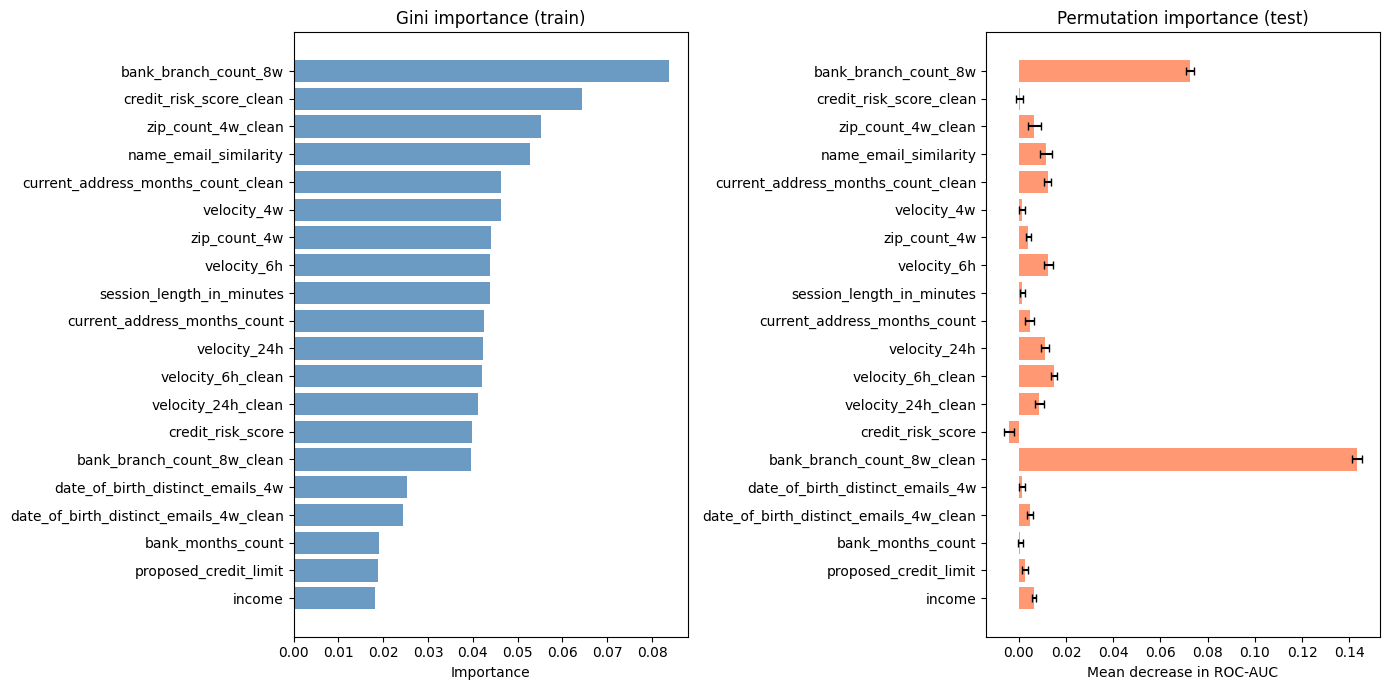

In [120]:
#визуализация
top20 = importance_combined.head(20).sort_values('Gini_train')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top20['Feature'], top20['Gini_train'], color='steelblue', alpha=0.8)
axes[0].set_title('Gini importance (train)')
axes[0].set_xlabel('Importance')

axes[1].barh(top20['Feature'], top20['Perm_test_mean'], color='coral', alpha=0.8)
axes[1].errorbar(
    top20['Perm_test_mean'], top20['Feature'],
    xerr=top20['Perm_test_std'],
    fmt='none', color='black', capsize=3
)
axes[1].set_title('Permutation importance (test)')
axes[1].set_xlabel('Mean decrease in ROC-AUC')

plt.tight_layout()
plt.show()

In [121]:
#Отбираем признаки с Gini на train > 0.001
selected_features = importance_combined[
    importance_combined['Gini_train'] > 0.001
]['Feature'].tolist()

print(f"Признаков до отбора: {X_train.shape[1]}")
print(f"Признаков после отбора: {len(selected_features)}")

# Флаг нестабильности: признак важен по Gini, но слаб на test
unstable = importance_combined[
    (importance_combined['Gini_train'] > 0.001) &
    (importance_combined['Perm_test_mean'] < 0)
]
if len(unstable) > 0:
    print(f"\nПризнаки с возможным переобучением ({len(unstable)} шт.):")
    print(unstable[['Feature', 'Gini_train', 'Perm_test_mean']].to_string(index=False))

Признаков до отбора: 58
Признаков после отбора: 48

Признаки с возможным переобучением (4 шт.):
               Feature  Gini_train  Perm_test_mean
     credit_risk_score    0.039850       -0.004210
intended_balcon_amount    0.009357       -0.000635
       payment_type_AB    0.004478       -0.000235
       payment_type_AA    0.002720       -0.000398


### Шаг 3 Корреляции

In [123]:
# корреляция всего с зависимой переменной
results = []
for col in df_train_test.select_dtypes(include=['float64', 'int64']).columns:
    if col == 'fraud_bool':
        continue
    corr, pval = stats.pointbiserialr(
        df_train_test['fraud_bool'],
        df_train_test[col].fillna(df_train_test[col].median())
    )
    results.append({
        'Feature': col,
        'PB_corr': round(corr, 4),
        'abs_corr': abs(corr),
        'p_value': round(pval, 6),
        'significant': pval < 0.05
    })

corr_df = pd.DataFrame(results).sort_values('abs_corr', ascending=False)
print(corr_df.to_string(index=False))

                               Feature  PB_corr  abs_corr  p_value  significant
               credit_risk_score_clean   0.0701  0.070073 0.000000         True
                     credit_risk_score   0.0667  0.066724 0.000000         True
                 proposed_credit_limit   0.0650  0.064986 0.000000         True
                          customer_age   0.0626  0.062630 0.000000         True
                    keep_alive_session  -0.0481  0.048127 0.000000         True
date_of_birth_distinct_emails_4w_clean  -0.0462  0.046154 0.000000         True
                                income   0.0431  0.043096 0.000000         True
      date_of_birth_distinct_emails_4w  -0.0428  0.042776 0.000000         True
    current_address_months_count_clean   0.0423  0.042263 0.000000         True
             device_distinct_emails_8w   0.0374  0.037357 0.000000         True
                 name_email_similarity  -0.0358  0.035762 0.000000         True
            bank_branch_count_8w_clean  

In [124]:
# убираем только те, что и слабые, и незначимые
weak_features = corr_df[
    (corr_df['abs_corr'] < 0.01) & (~corr_df['significant'])
]['Feature'].tolist()

print(f"Кандидаты на удаление: {weak_features}")

Кандидаты на удаление: ['intended_balcon_amount']


In [126]:
# корреляция всего со всем
def calc_vif(X):
    X_filled = X.fillna(X.median())
    vif_data = pd.DataFrame({
        'Feature': X_filled.columns,
        'VIF': [variance_inflation_factor(X_filled.values, i)
                for i in range(X_filled.shape[1])]
    }).sort_values('VIF', ascending=False)
    return vif_data

# итеративно убираем признак с максимальным VIF пока все не станут < 10
X_vif = df_train_test.select_dtypes(include=['float64', 'int64']).drop(columns=['fraud_bool'])
removed = []

while True:
    vif = calc_vif(X_vif)
    max_vif = vif.iloc[0]
    if max_vif['VIF'] < 10:
        break
    print(f"Удаляем {max_vif['Feature']} (VIF={max_vif['VIF']:.1f})")
    removed.append(max_vif['Feature'])
    X_vif = X_vif.drop(columns=[max_vif['Feature']])

print(f"\nУдалено признаков: {len(removed)}: {removed}")
print(f"Осталось признаков: {X_vif.shape[1]}")

Удаляем velocity_24h_clean (VIF=220.5)
Удаляем velocity_6h_clean (VIF=74.0)
Удаляем velocity_4w (VIF=61.0)
Удаляем credit_risk_score_clean (VIF=58.6)
Удаляем date_of_birth_distinct_emails_4w_clean (VIF=39.6)
Удаляем device_distinct_emails_8w (VIF=22.7)
Удаляем velocity_24h (VIF=16.1)

Удалено признаков: 7: ['velocity_24h_clean', 'velocity_6h_clean', 'velocity_4w', 'credit_risk_score_clean', 'date_of_birth_distinct_emails_4w_clean', 'device_distinct_emails_8w', 'velocity_24h']
Осталось признаков: 25


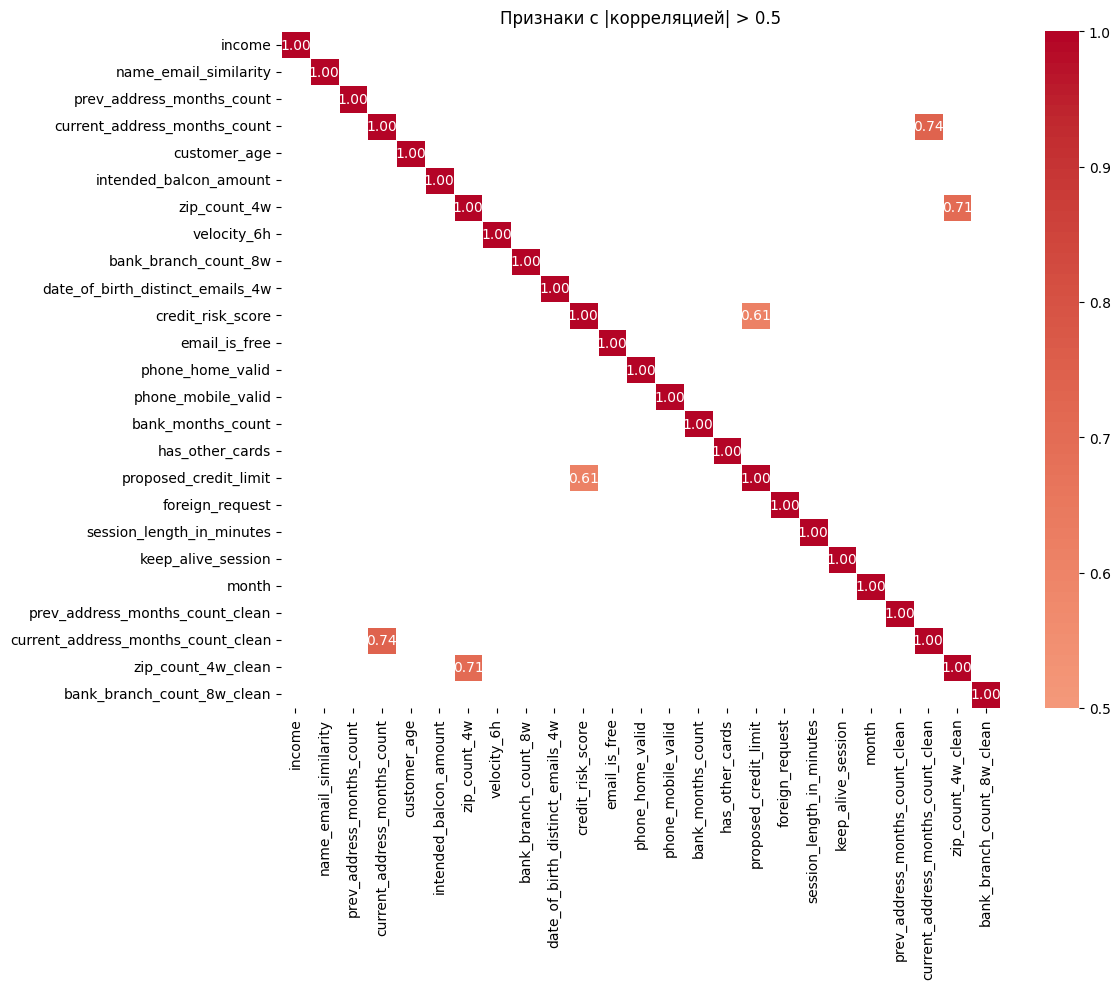

In [127]:
corr_matrix = X_vif.corr().abs()

# показываем только пары с |corr| > 0.5
mask = corr_matrix < 0.5
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=0.5, vmax=1.0,
    linewidths=0.5
)
plt.title('Признаки с |корреляцией| > 0.5')
plt.tight_layout()
plt.show()

##Итог

In [139]:
#собираем все списки исключений из предыдущих шагов

#после Джини
df_train_test = df_train_test[selected_features]
df_train_test

,bank_branch_count_8w,credit_risk_score_clean,zip_count_4w_clean,name_email_similarity,current_address_months_count_clean,velocity_4w,zip_count_4w,velocity_6h,session_length_in_minutes,current_address_months_count,...,device_os_other,device_os_linux,housing_status_BC,employment_status_CC,employment_status_CB,housing_status_BB,device_os_macintosh,payment_type_AA,housing_status_BE,housing_status_BD
0,5,163.0,1059.0,0.986506,25.0,6742.080561,1059,13096.035018,16.224843,25.0,...,False,True,True,False,True,False,False,True,False,False
1,3,154.0,1658.0,0.617426,89.0,5941.664859,1658,9223.283431,3.363854,89.0,...,True,False,True,False,False,False,False,False,False,False
2,15,89.0,1095.0,0.996707,14.0,5992.555113,1095,4471.472149,22.730559,14.0,...,False,False,True,False,False,False,False,False,False,False
3,11,90.0,3483.0,0.475100,14.0,5970.336831,3483,14431.993621,15.215816,14.0,...,False,True,True,False,False,False,False,False,False,False
4,1,91.0,2339.0,0.842307,29.0,5940.734212,2339,7601.511579,3.743048,29.0,...,True,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794984,0,287.0,173.0,0.595063,41.0,4115.700110,173,8748.840025,5.889926,41.0,...,False,False,False,False,False,False,False,False,False,False
794985,1,257.0,903.0,0.302105,190.0,4248.463544,903,6376.849688,2.448131,190.0,...,False,False,False,False,False,False,False,False,False,False
794986,1,256.0,900.0,0.278439,97.0,4190.404284,900,5872.242985,3.061090,97.0,...,False,False,False,False,False,False,False,False,False,False
794987,0,261.0,849.0,0.337855,135.0,4441.715705,849,3974.154245,4.389002,135.0,...,False,False,False,False,False,True,False,False,False,False


In [150]:
#оставшиеся "грязные" переменные, если есть чистые в итоговом датасете
leftovers = ['zip_count_4w', 'current_address_months_count', 'bank_branch_count_8w', 'prev_address_months_count']

In [151]:
# корреляции с таргетом
dropped_low_corr = weak_features

# из мультиколлинеарности
dropped_multicoll = removed

all_dropped = (dropped_low_corr +
    dropped_multicoll +
               leftovers
)

# --- применяем только те, что реально есть в df ---
to_drop = [col for col in all_dropped if col in df_train_test.columns]
not_found = [col for col in all_dropped if col not in df_train_test.columns]


df_train_test = df_train_test.drop(columns=to_drop)

print(f"Удалено признаков:  {len(to_drop)}")
print(f"Осталось признаков: {df_train_test.shape[1] - 1}")  # -1 это таргет
print(f"\nФинальные признаки:")
final_features = [c for c in df_train_test.columns if c != 'fraud_bool']
for f in final_features:
    print(f"  {f}")

Удалено признаков:  4
Осталось признаков: 35

Финальные признаки:
  zip_count_4w_clean
  name_email_similarity
  current_address_months_count_clean
  velocity_6h
  session_length_in_minutes
  credit_risk_score
  bank_branch_count_8w_clean
  date_of_birth_distinct_emails_4w
  bank_months_count
  proposed_credit_limit
  income
  customer_age
  month
  prev_address_months_count_clean
  housing_status_BA
  device_os_windows
  email_is_free
  phone_home_valid
  keep_alive_session
  phone_mobile_valid
  payment_type_AB
  has_other_cards
  payment_type_AC
  employment_status_CA
  foreign_request
  payment_type_AD
  device_os_other
  device_os_linux
  housing_status_BC
  employment_status_CC
  employment_status_CB
  housing_status_BB
  device_os_macintosh
  payment_type_AA
  housing_status_BE
  housing_status_BD


In [152]:
#выгрузим итоговые таблицы
df_train_test.to_csv('df_train_test_clean.csv', index=False)
df_oot.to_csv('df_oot_clean.csv', index=False)

print(f"df_train_test_clean.csv — {df_train_test.shape[0]:,} строк, {df_train_test.shape[1]} колонок")
print(f"df_oot_clean.csv        — {df_oot.shape[0]:,} строк, {df_oot.shape[1]} колонок")
print(f"\nПризнаки: {[c for c in df_train_test.columns if c != 'fraud_bool']}")

df_train_test_clean.csv — 794,989 строк, 36 колонок
df_oot_clean.csv        — 205,011 строк, 32 колонок

Признаки: ['zip_count_4w_clean', 'name_email_similarity', 'current_address_months_count_clean', 'velocity_6h', 'session_length_in_minutes', 'credit_risk_score', 'bank_branch_count_8w_clean', 'date_of_birth_distinct_emails_4w', 'bank_months_count', 'proposed_credit_limit', 'income', 'customer_age', 'month', 'prev_address_months_count_clean', 'housing_status_BA', 'device_os_windows', 'email_is_free', 'phone_home_valid', 'keep_alive_session', 'phone_mobile_valid', 'payment_type_AB', 'has_other_cards', 'payment_type_AC', 'employment_status_CA', 'foreign_request', 'payment_type_AD', 'device_os_other', 'device_os_linux', 'housing_status_BC', 'employment_status_CC', 'employment_status_CB', 'housing_status_BB', 'device_os_macintosh', 'payment_type_AA', 'housing_status_BE', 'housing_status_BD']
